In [1]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import random

In [2]:
data=pd.read_csv("cleaning.csv")
data.info()
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2369 entries, 0 to 2368
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              2369 non-null   object 
 1   Venue_Categories  2369 non-null   object 
 2   Destination       2369 non-null   object 
 3   Ratings           2369 non-null   float64
 4   Reviews           2369 non-null   float64
 5   Menu_price        2369 non-null   int64  
 6   Capacity_min      2369 non-null   int64  
 7   Capacity_max      2369 non-null   int64  
 8   Rooms             2369 non-null   int64  
 9   Amenties_more     2369 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 185.2+ KB


,Name,Venue_Categories,Destination,Ratings,Reviews,Menu_price,Capacity_min,Capacity_max,Rooms,Amenties_more
0,Jade Luxury Banquets,Sea View Banquet & Lawn,Mumbai,5.0,12.0,3200,30,600,20,3
1,The Lalit Mumbai,5 Star Hotel,Mumbai,4.9,16.0,3800,50,1000,389,4
2,Kumar Resort by TURTLE,Resort Near Mumbai,Mumbai,5.0,2.0,1499,80,2000,90,5
3,"Whistling Woodzs Jungle Resort, Dandeli",Lake View/River View\t,Mumbai,5.0,2.0,999,50,400,100,3
4,Fairfield by Marriott Mumbai International Air...,Hotel with Banquet & Lawn,Mumbai,5.0,3.0,3000,50,1150,205,5
...,...,...,...,...,...,...,...,...,...,...
2364,RP Palace,Wedding Lawn,Lucknow,4.9,3.8,400,150,250,20,2
2365,Hotel Maharaja Delight Lawn,Lawn & Banquet Hall,Lucknow,4.9,3.8,650,100,400,15,3
2366,Rajkamal Palace,Banquet Hall & Lawn,Lucknow,4.9,3.8,350,200,400,20,2
2367,Shivaay Lawn,Wedding Lawn,Lucknow,4.9,3.8,700,600,1000,20,2


In [3]:
numerical_columns = data.select_dtypes(include= ['int64','float64']).columns.tolist()
categorical_columns= data.select_dtypes(include= ['object']).columns.tolist()
numerical_columns, categorical_columns

(['Ratings',
  'Reviews',
  'Menu_price',
  'Capacity_min',
  'Capacity_max',
  'Rooms',
  'Amenties_more'],
 ['Name', 'Venue_Categories', 'Destination'])

In [4]:
print(numerical_columns)
print('-'*50)
print(categorical_columns)

['Ratings', 'Reviews', 'Menu_price', 'Capacity_min', 'Capacity_max', 'Rooms', 'Amenties_more']
--------------------------------------------------
['Name', 'Venue_Categories', 'Destination']


# Univariate Analysis

**Distribution of Data**

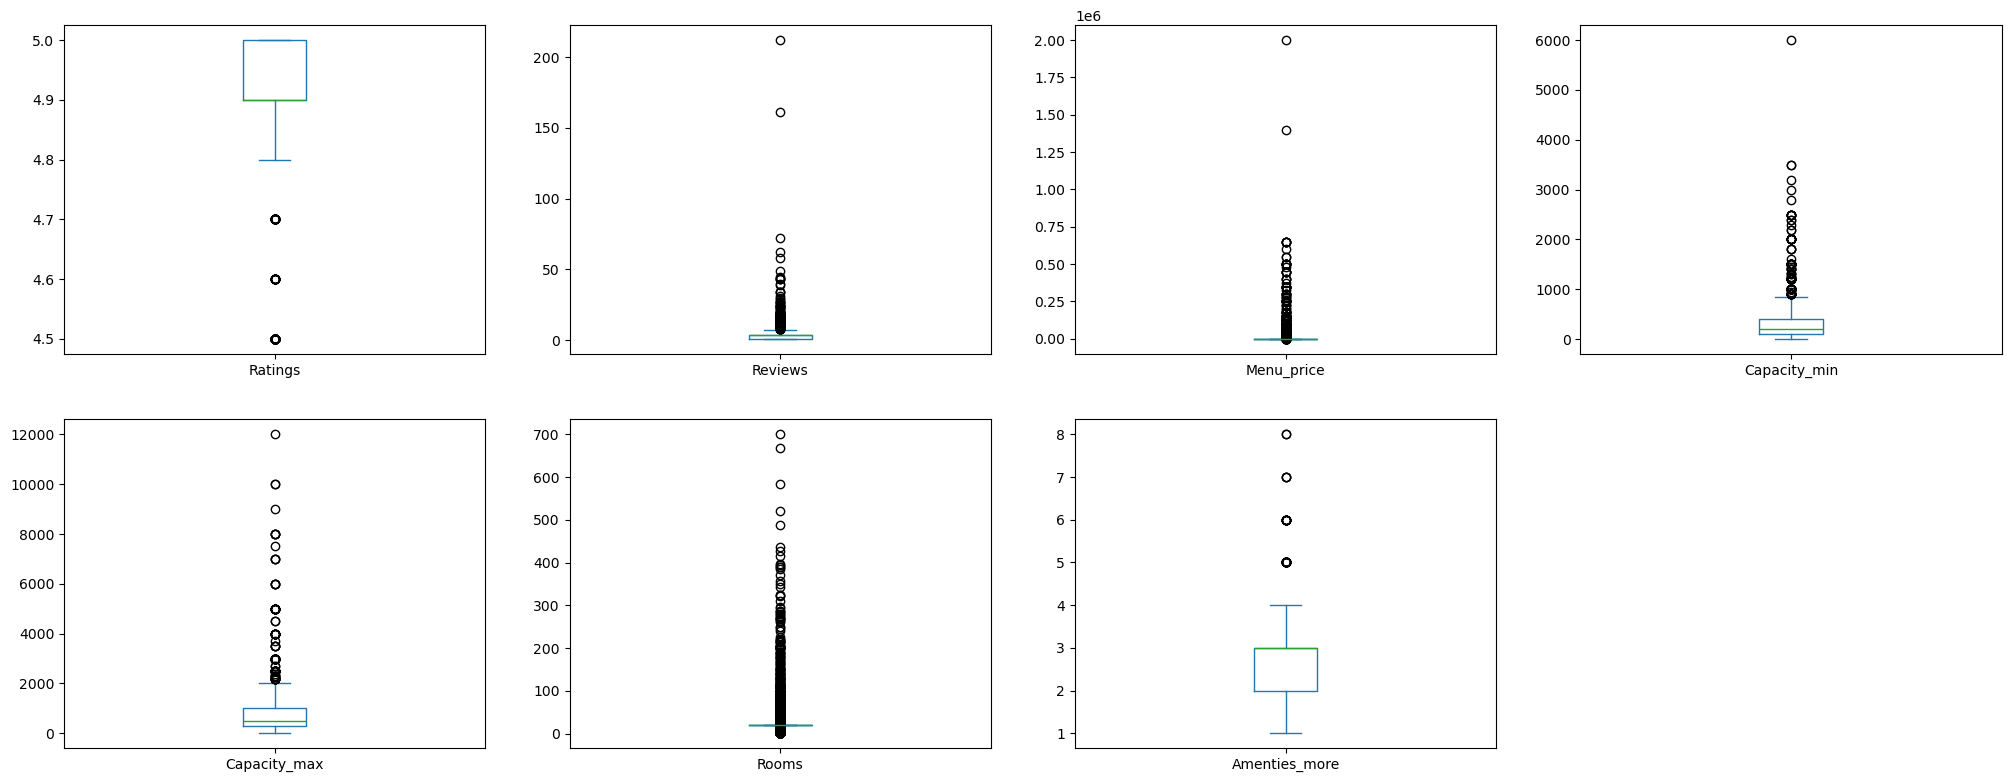

In [5]:
data[numerical_columns].plot(kind= 'box',
                            subplots= True,
                            figsize=(25,35),
                            layout= (7,4))
plt.savefig("Box plot of all Numerical Columns.png")

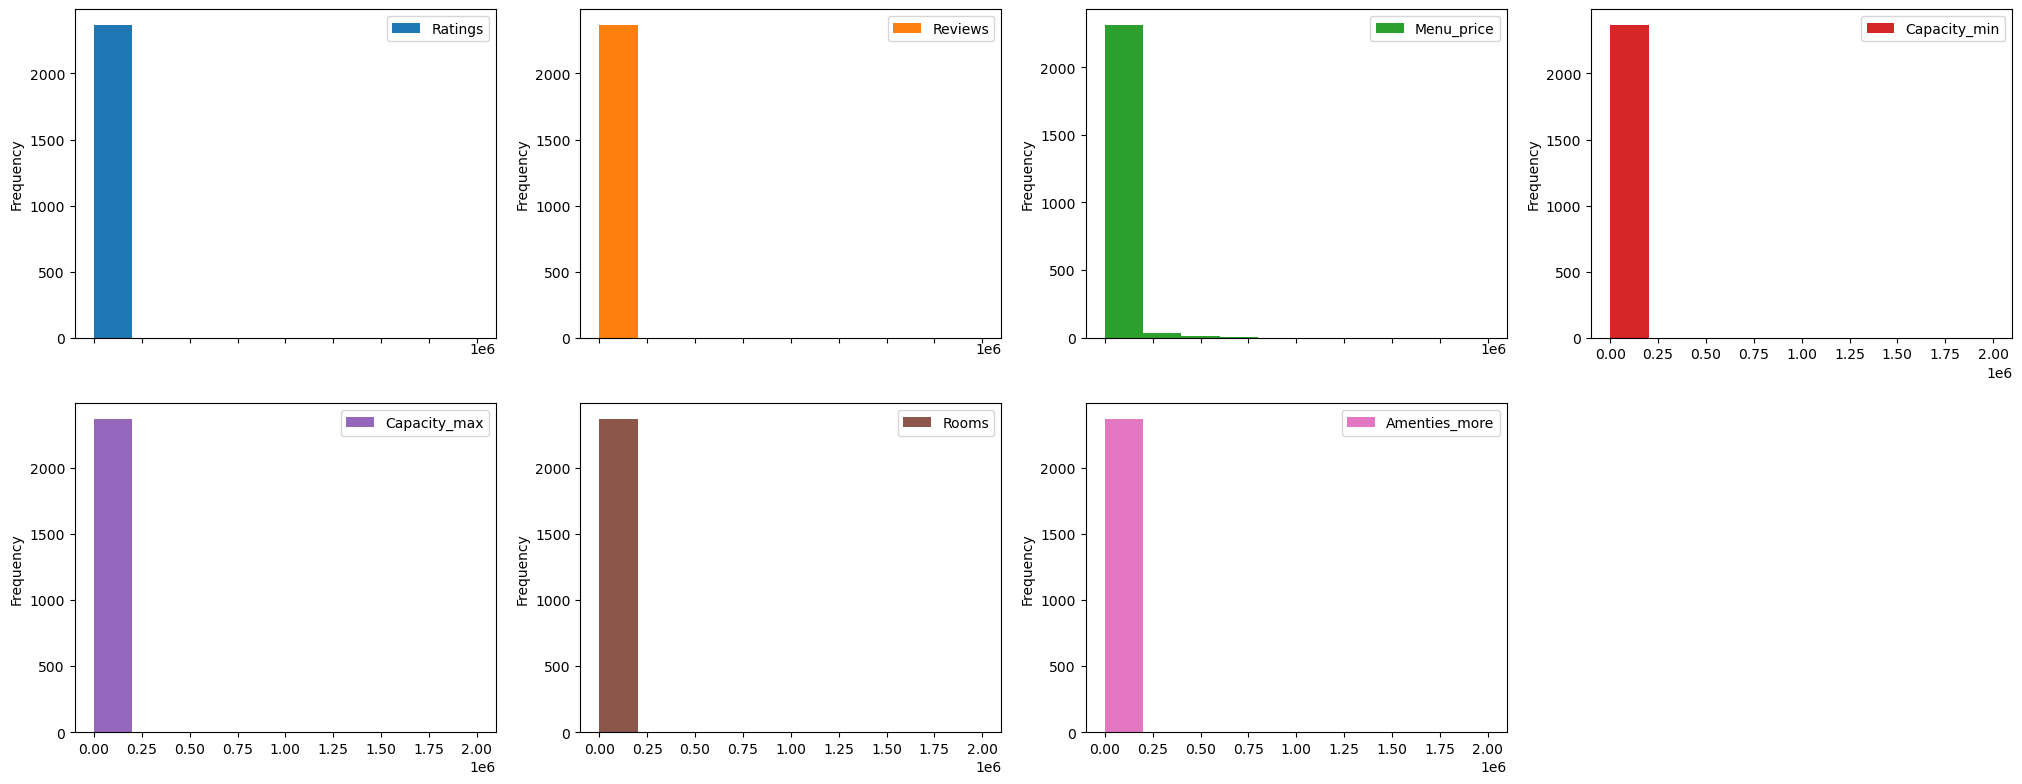

In [6]:
data[numerical_columns].plot(kind= 'hist',
                            subplots= True,
                            figsize=(25,35),
                            layout= (7,4))
plt.savefig("Hisrogram of all Numerical Columns.png")

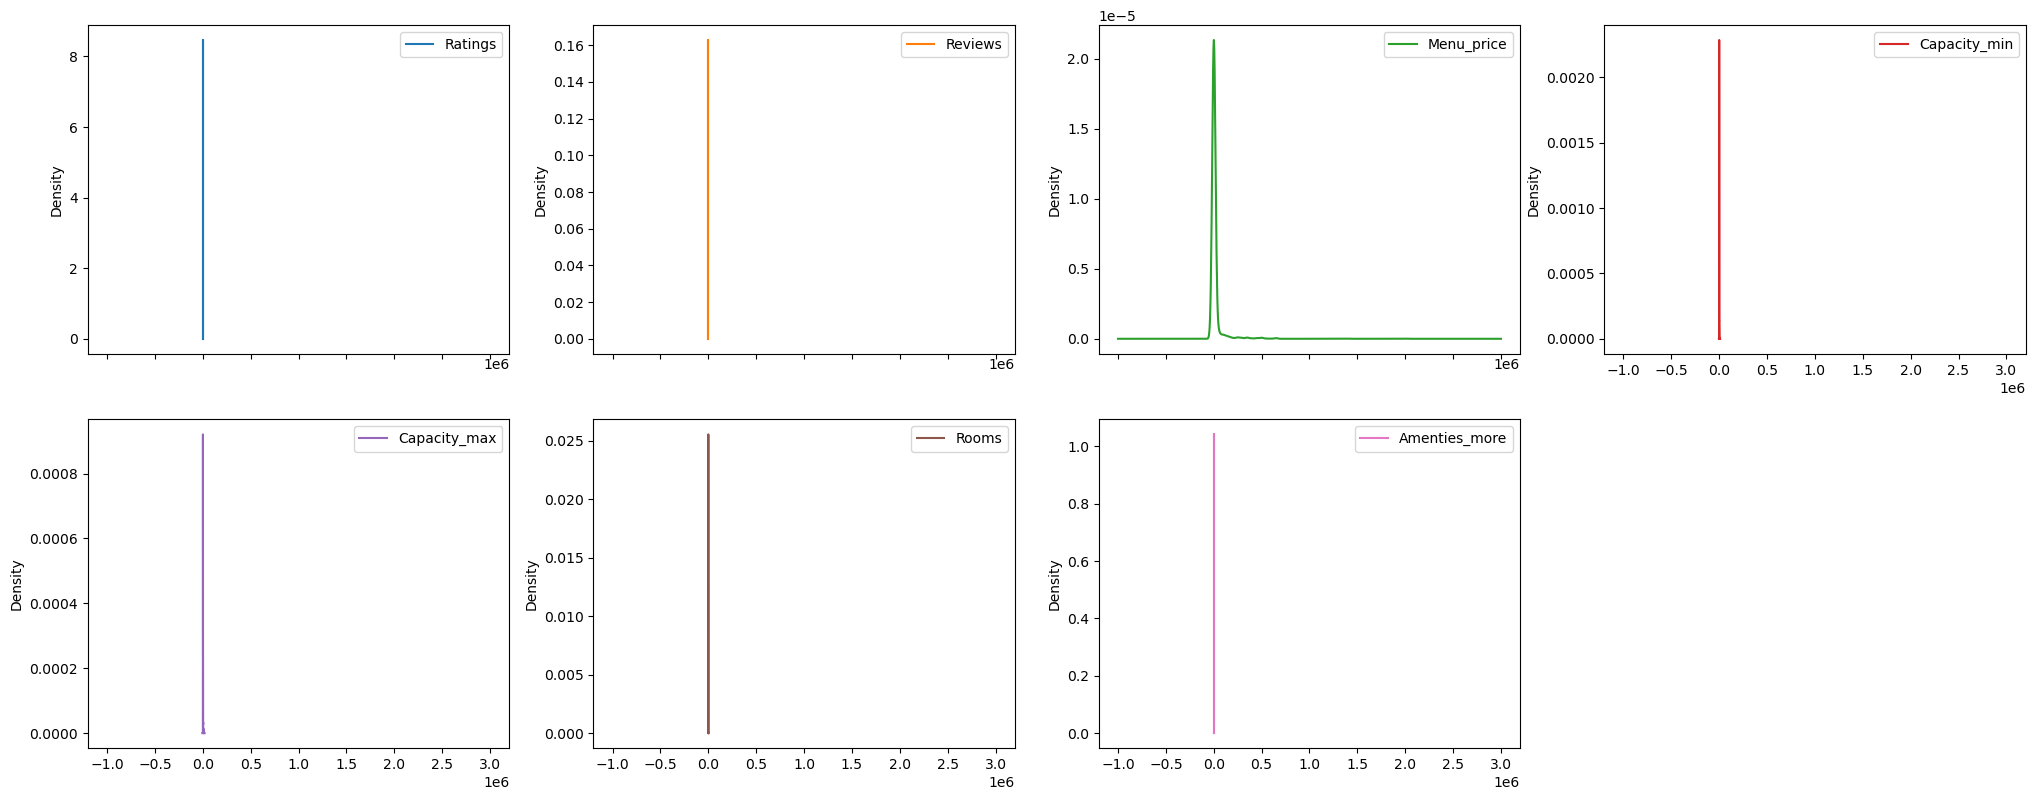

In [6]:
data[numerical_columns].plot(kind= 'kde',
                            subplots= True,
                            figsize=(25,35),
                            layout= (7,4))
plt.savefig("KDE plot of all Numerical Columns.png")

## Numerical data

# Ratings

In [7]:
def numerical(df,column):
    print(df[column].agg(['min','max','mean','median','std','skew']))
    print()
    ## Distribution
    plt.figure(figsize=(15,10))
    ## histogram
    plt.subplot(2,2,1)
    df[column].plot(kind='hist',bins= 10,edgecolor="black",color="violet")
    plt.title('Histogram plot')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    ##KDE
    plt.subplot(2,2,2)
    df[column].plot(kind='kde',color="red")
    plt.title('KDE plot')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    ##Box plot
    plt.subplot(2,2,3)
    df[column].plot(kind='box',color="blue")
    plt.title('Box plot')
    plt.savefig(f"{column}_plots.png") 
    plt.suptitle("Univariate analysis on numerical columns", fontsize=16)

In [8]:
def iqr(data,column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    data_no_outliers = data[(data[column] >= Q1 - 1.5*IQR) & (data[column] <= Q3 + 1.5*IQR)]
    print(len(data_no_outliers))
    plt.figure(figsize=(8,6))
    plt.boxplot(data_no_outliers[column])
    plt.ylabel("Ratings")
    plt.savefig(f"{column}_After handling outliers.png")
    plt.show()
    return data_no_outliers

min       4.500000
max       5.000000
mean      4.914732
median    4.900000
std       0.110847
skew     -2.363556
Name: Ratings, dtype: float64

None
--------------------------------------------------
2211


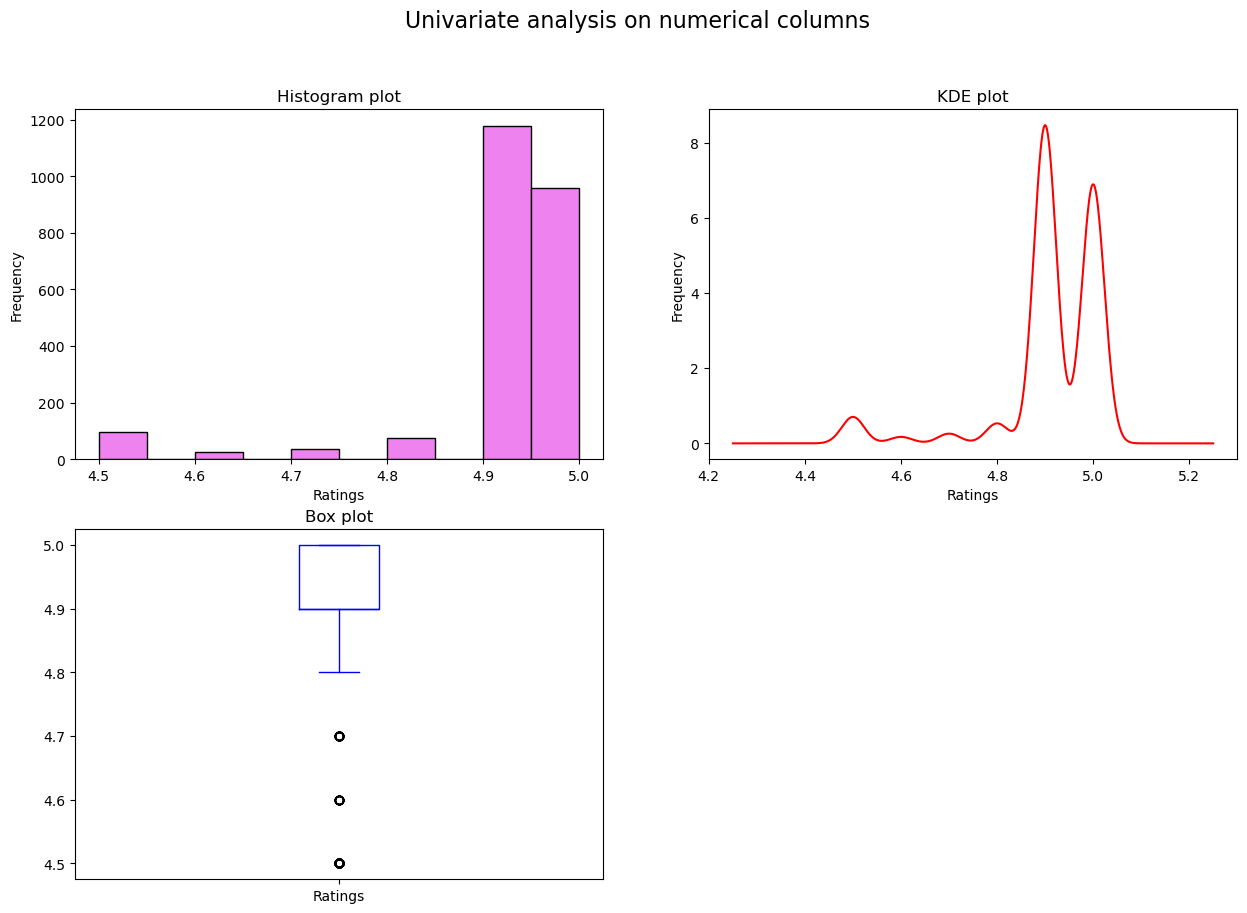

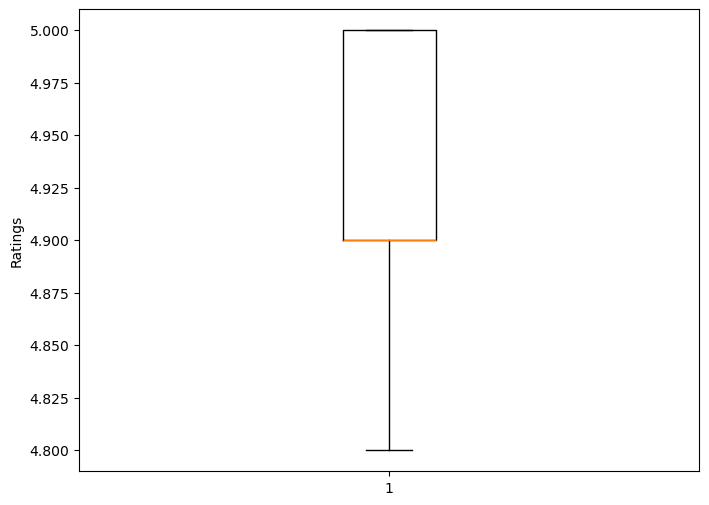

                                                   Name  \
0                                  Jade Luxury Banquets   
1                                      The Lalit Mumbai   
2                                Kumar Resort by TURTLE   
3               Whistling Woodzs Jungle Resort, Dandeli   
4     Fairfield by Marriott Mumbai International Air...   
...                                                 ...   
2364                                          RP Palace   
2365                        Hotel Maharaja Delight Lawn   
2366                                    Rajkamal Palace   
2367                                       Shivaay Lawn   
2368                                            PS Lawn   

               Venue_Categories Destination  Ratings  Reviews  Menu_price  \
0       Sea View Banquet & Lawn      Mumbai      5.0     12.0        3200   
1                  5 Star Hotel      Mumbai      4.9     16.0        3800   
2            Resort Near Mumbai      Mumbai      5.0      2.

In [9]:
print(numerical(data,'Ratings'))
print('-'*50)
print(iqr(data,'Ratings'))

# `Observations`

**1. Histogram**
- Most of the ratings are clustered very high, between 4.9 and 5.0.
- There are a few ratings between 4.5 and 4.7, but the vast majority falls in the top bin.
  
**2. KDE plot**
- This smooth curve shows that the ratings have two main peaks.
- The largest peak is very close to 5.0, and there is a smaller, noticeable peak around 4.9.
- There are also a few tiny bumps around 4.5 and 4.6.
  
**3. Box plot(Before handling outliers)**
- The box itself, which represents the middle 50% of the ratings, is extremely small and located very close to 4.9.
- The line inside the box (the median) is near the top of the box.
- There are several individual points (circles) scattered below the main group, ranging from about 4.5 to 4.7.


 # Box plot(After handling outliers): 
`Observations`:
- The boxplot is centered tightly around values between 4.8 and 5.0.
- The median (orange line) is around 4.9.
- The interquartile range (IQR) is very small, showing that most data points are very close to each other.
- There are no visible outliers in this plot (suggesting outliers were successfully handled/removed).
- The data is slightly skewed downward (longer whisker on the lower side).

# Reviews

min         1.000000
max       212.000000
mean        3.812832
median      3.800000
std         7.166024
skew       16.611807
Name: Reviews, dtype: float64

None
--------------------------------------------------
2202


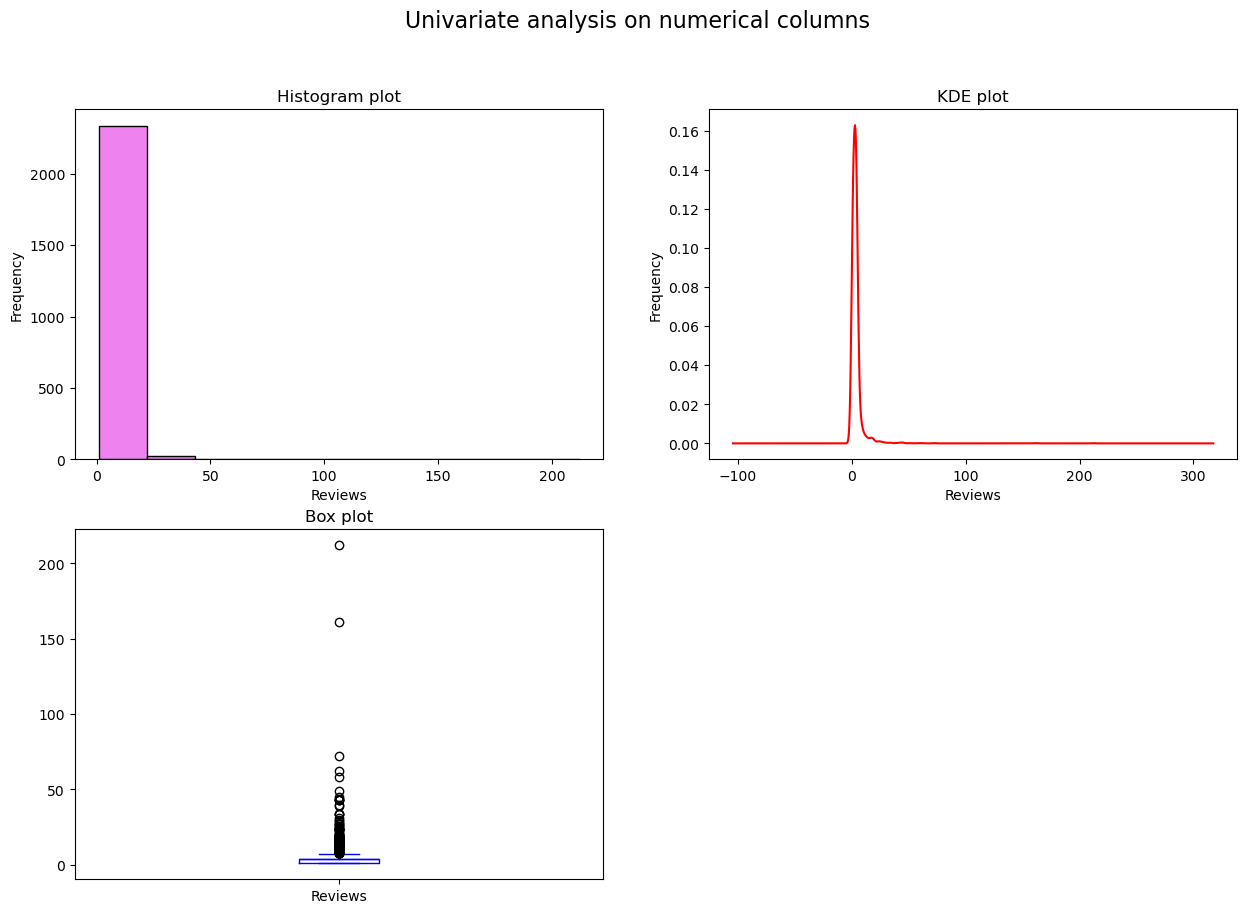

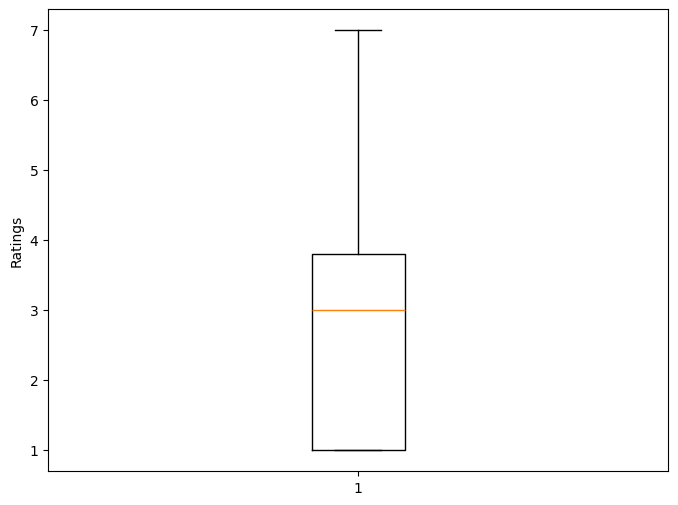

                                                   Name  \
2                                Kumar Resort by TURTLE   
3               Whistling Woodzs Jungle Resort, Dandeli   
4     Fairfield by Marriott Mumbai International Air...   
5                                     Chandivali Studio   
8             Radisson Blu Mumbai International Airport   
...                                                 ...   
2364                                          RP Palace   
2365                        Hotel Maharaja Delight Lawn   
2366                                    Rajkamal Palace   
2367                                       Shivaay Lawn   
2368                                            PS Lawn   

               Venue_Categories Destination  Ratings  Reviews  Menu_price  \
2            Resort Near Mumbai      Mumbai      5.0      2.0        1499   
3        Lake View/River View\t      Mumbai      5.0      2.0         999   
4     Hotel with Banquet & Lawn      Mumbai      5.0      3.

In [10]:
print(numerical(data,'Reviews'))
print('-'*50)
print(iqr(data,'Reviews'))

# `Observations:`
**1. Histogram Plot:**
- Almost all of the reviews are squeezed into the very first bar (near the number 0).
- The height of this bar is around 2250, while the rest of the bars are barely visible.

**2. KDE Plot:**
- The curve shows one extremely tall and thin spike right around the number 0. 
- The curve immediately drops back down and remains flat for the rest of the graph.

**3. Box Plot(Before handling outliers):**
- The main box and the whiskers are extremely small and located right at the bottom (near the number 0).
- There are many individual dots (outliers) scattered above the main box, some reaching as high as 150.

# Box plot(After handling outliers): 
`Observations`:
- The box, which represents the middle 50% of the review counts, is quite large and extends from **1 to 3.5**.
-  The line inside the box (the median) is located at **3.5**.
-  The upper whisker goes up to 7, and there are no individual dots or circles outside of the whiskers.

# Amenities

min       1.000000
max       8.000000
mean      2.729422
median    3.000000
std       0.786703
skew      1.308674
Name: Amenties_more, dtype: float64

None
--------------------------------------------------
2320


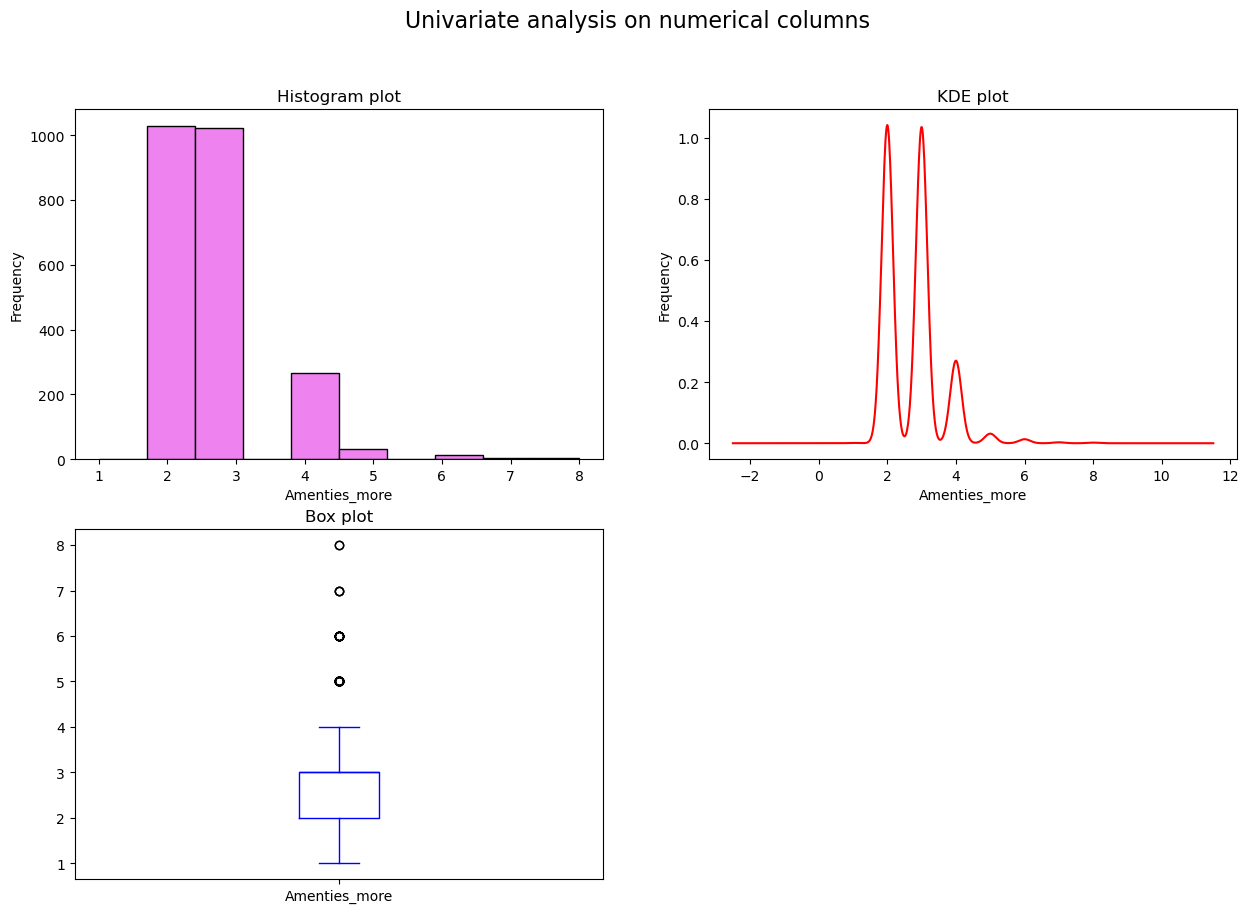

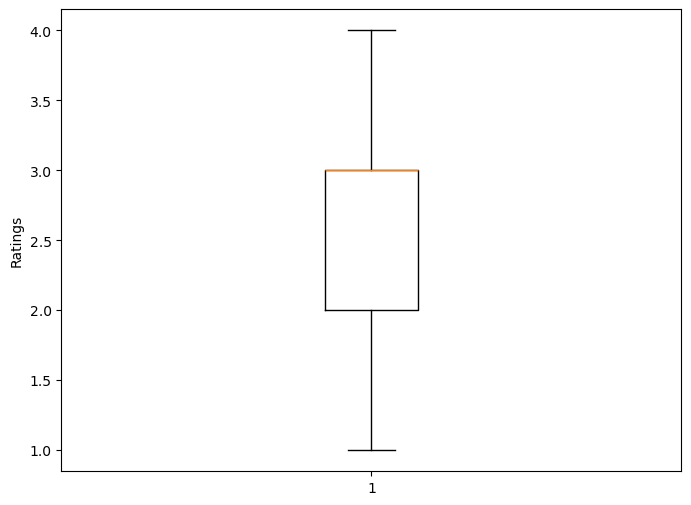

                                           Name           Venue_Categories  \
0                          Jade Luxury Banquets    Sea View Banquet & Lawn   
1                              The Lalit Mumbai               5 Star Hotel   
3       Whistling Woodzs Jungle Resort, Dandeli     Lake View/River View\t   
5                             Chandivali Studio               Wedding Lawn   
8     Radisson Blu Mumbai International Airport  5 Star Hotel Near Airport   
...                                         ...                        ...   
2364                                  RP Palace               Wedding Lawn   
2365                Hotel Maharaja Delight Lawn        Lawn & Banquet Hall   
2366                            Rajkamal Palace        Banquet Hall & Lawn   
2367                               Shivaay Lawn               Wedding Lawn   
2368                                    PS Lawn        Lawn & Banquet Hall   

     Destination  Ratings  Reviews  Menu_price  Capacity_min  C

In [11]:
print(numerical(data,'Amenties_more'))
print('-'*50)
print(iqr(data,'Amenties_more')) 

# `Observations:`

**1. Histogram:**
- The bars of amenities for counts 1 and 2 are the tallest, showing they are the most common values.
- The count drops quickly after that, meaning very few items have 3 or more extra amenities.

**2. KDE Plot:** 
- The smooth red curve has **two very high, sharp peaks** located at **1 and 2**.
- There's a much smaller, third peak at **4**. 

**3 . Box Plot(Before handling outliers):**
- the box, which holds the middle half of the data, is small and centered between **1 and 3**. 
- The line inside the box (the median) is at **2**.
- There are several **dots (outliers)** scattered above the box at 5, 6, and 7.

# Box plot(After handling outliers): 
`Observations`:
- The box, representing the middle **50% of the data**, is located between **2 and 3**.
- The line inside the box (the median) is at **3**.
- The entire range of the data, from the bottom of the lower whisker to the top of the upper whisker, spans from **1 to 4**.
- Crucially, there are **no individual dots or circles** (outliers) outside of the whiskers.

## Menu_price

min       2.300000e+01
max       2.000000e+06
mean      1.563824e+04
median    6.500000e+02
std       8.141019e+04
skew      1.136257e+01
Name: Menu_price, dtype: float64

None
--------------------------------------------------
2028


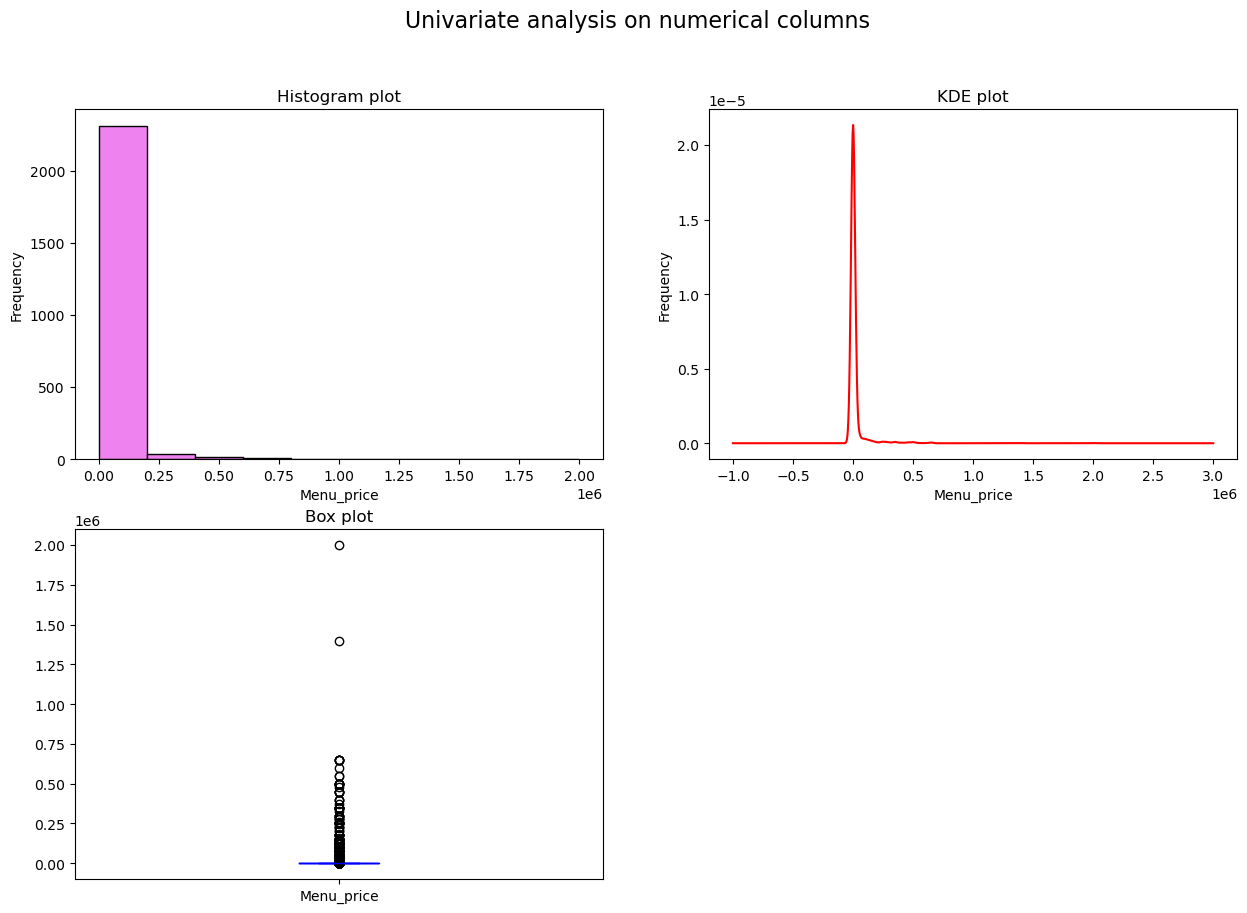

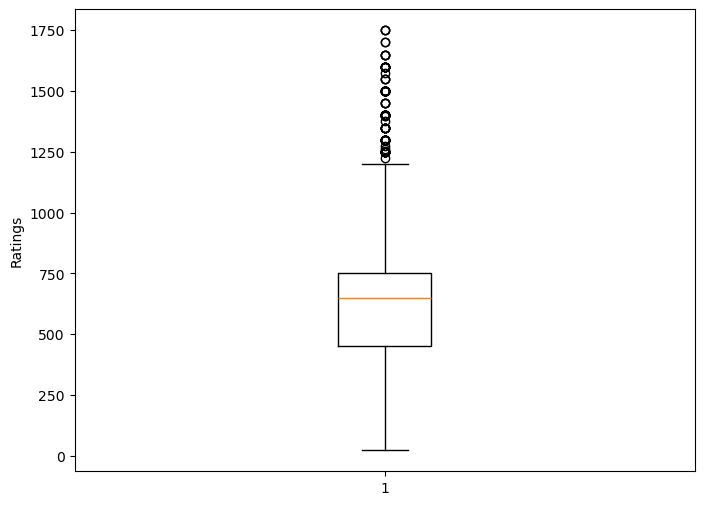

                                                   Name  \
2                                Kumar Resort by TURTLE   
3               Whistling Woodzs Jungle Resort, Dandeli   
5                                     Chandivali Studio   
10                                   GCC Hotel And Club   
12    Canossa Lawn, Hall & Auditorium - mgd by Micha...   
...                                                 ...   
2363                                        Hotel Mahak   
2364                                          RP Palace   
2365                        Hotel Maharaja Delight Lawn   
2366                                    Rajkamal Palace   
2367                                       Shivaay Lawn   

               Venue_Categories Destination  Ratings  Reviews  Menu_price  \
2            Resort Near Mumbai      Mumbai      5.0      2.0        1499   
3        Lake View/River View\t      Mumbai      5.0      2.0         999   
5                  Wedding Lawn      Mumbai      4.9      5.

In [12]:
print(numerical(data,'Menu_price'))
print('-'*50)
print(iqr(data,'Menu_price')) 

# `Observations`

**1. Histogram**
- Almost all menu_prices are concentrated in the very first bar, which is right near zero on the price axis.
- This bar is extremely tall (around 2250), and the rest of the bars are barely visible.
  
**2. KDE plot**
- The curve shows a single, extremely high, thin spike precisely at the number 0.
- The curve immediately drops to zero and stays flat across the rest of the price range.
  
**3. Box plot(Before handling outliers)**
- The main box and the whiskers are squashed almost flat right on the zero line.
- There are many individual dots (outliers) scattered high above the box, with some reaching prices over 3,000,000 (3.5 million).


 # Box plot(After handling outliers): 
`Observations`:
- The main box, representing the middle 50% of prices, is very **narrow and low**, sitting just above the 0 line, roughly between **$0 and $2,000**.
- The upper whisker is also very short. However, there is a **large vertical column of individual dots (outliers)** scattered all the way up the chart, with prices reaching over **$50,000.**

## Capacity_min

min          8.000000
max       6000.000000
mean       321.852258
median     200.000000
std        381.851537
skew         4.251612
Name: Capacity_min, dtype: float64

None
--------------------------------------------------
2217


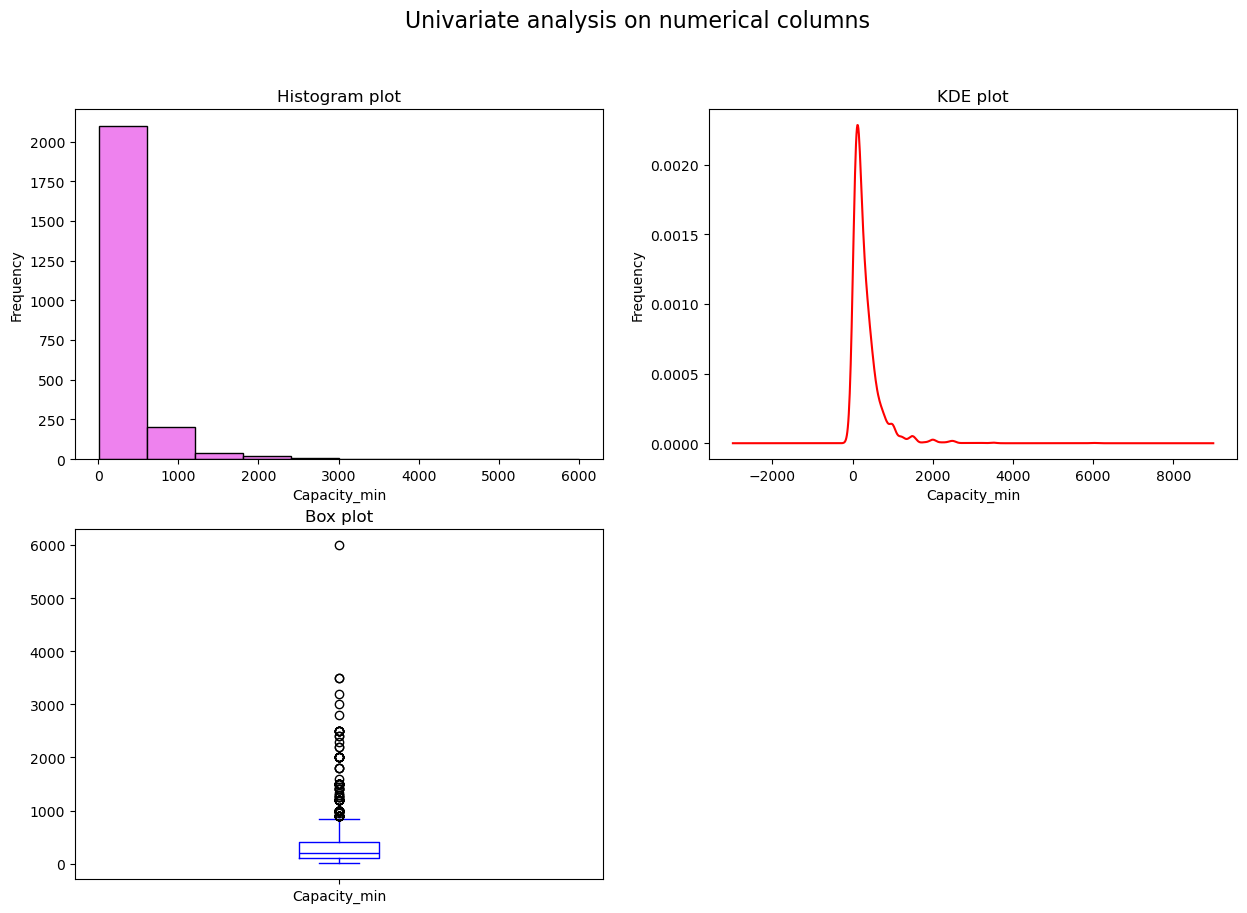

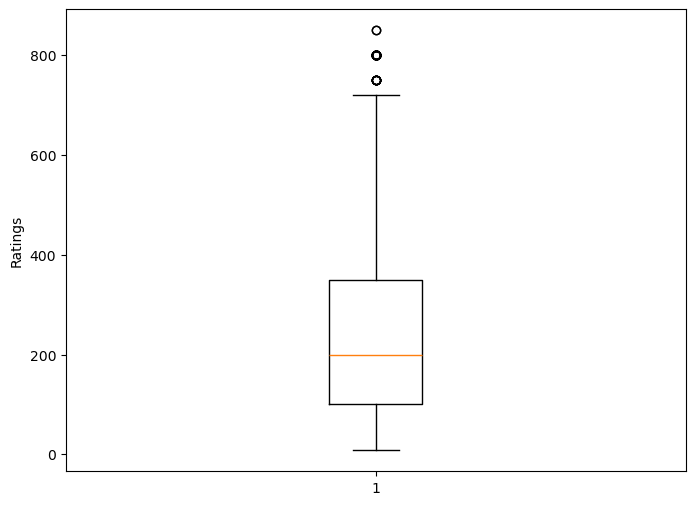

                                                   Name  \
0                                  Jade Luxury Banquets   
1                                      The Lalit Mumbai   
2                                Kumar Resort by TURTLE   
3               Whistling Woodzs Jungle Resort, Dandeli   
4     Fairfield by Marriott Mumbai International Air...   
...                                                 ...   
2364                                          RP Palace   
2365                        Hotel Maharaja Delight Lawn   
2366                                    Rajkamal Palace   
2367                                       Shivaay Lawn   
2368                                            PS Lawn   

               Venue_Categories Destination  Ratings  Reviews  Menu_price  \
0       Sea View Banquet & Lawn      Mumbai      5.0     12.0        3200   
1                  5 Star Hotel      Mumbai      4.9     16.0        3800   
2            Resort Near Mumbai      Mumbai      5.0      2.

In [13]:
print(numerical(data,'Capacity_min'))
print('-'*50)
print(iqr(data,'Capacity_min')) 

# `Observations`

**1. Histogram**
- Most of the data points fall into the very first bin, which is **closest to zero** (around 0 to 500).
- The number of data points drops off **very sharply** as you move to the right (higher capacity values). There are a few small bars for higher capacities, but they are very rare.

**2. KDE plot**
- There's a **very tall, thin peak** centered slightly above zero.
- The line quickly drops to near zero and stays flat for the rest of the graph, except for some tiny, minor bumps further to the right.

**3. Box plot(Before Handling Outliers)**
- The **box** itself (which represents the middle 50% of the data) is **extremely small** and sits right near the **zero line**.
- The line inside the box (the median) is also very close to zero.
- There is a **large number of individual dots** scattered above the box, reaching up to almost 7000.

 # Box plot(After handling outliers): 
`Observations`:
- The box itself is now much **larger and more visible** than in the previous plot, spanning a range from around 100 up to 350. This box represents the middle 50% of the minimum capacity values.
- The **line inside the box (the median)** is positioned slightly below the center of the box, near the **200 mark**.
- The whiskers (the lines extending from the box) reach down to 0 and up to about 750.
- There are **very few individual dots (outliers)** remaining above the top whisker, only a couple around the **800-900** mark.

# Capacity_max

min           4.000000
max       12000.000000
mean        805.810046
median      500.000000
std         962.018251
skew          4.288671
Name: Capacity_max, dtype: float64

None
--------------------------------------------------
2237


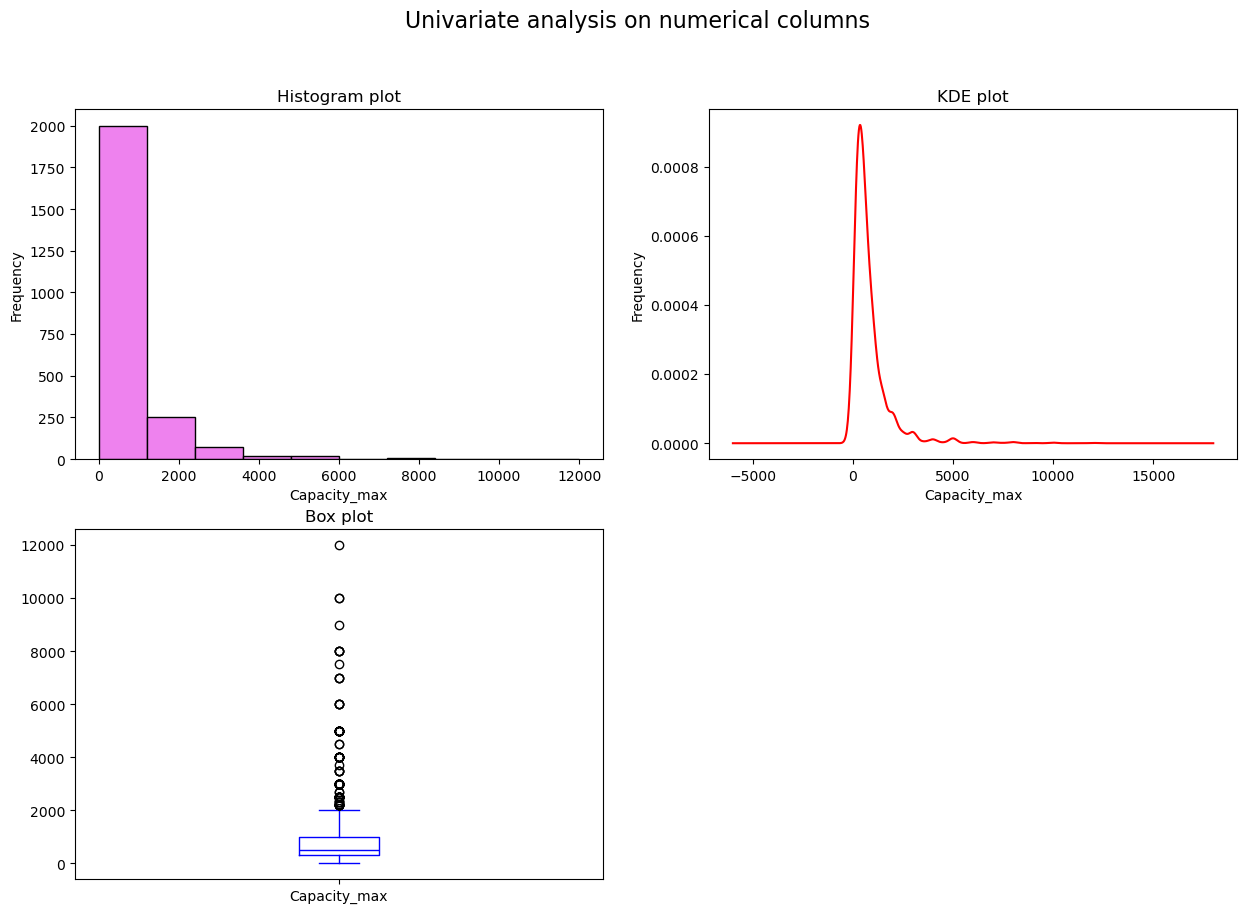

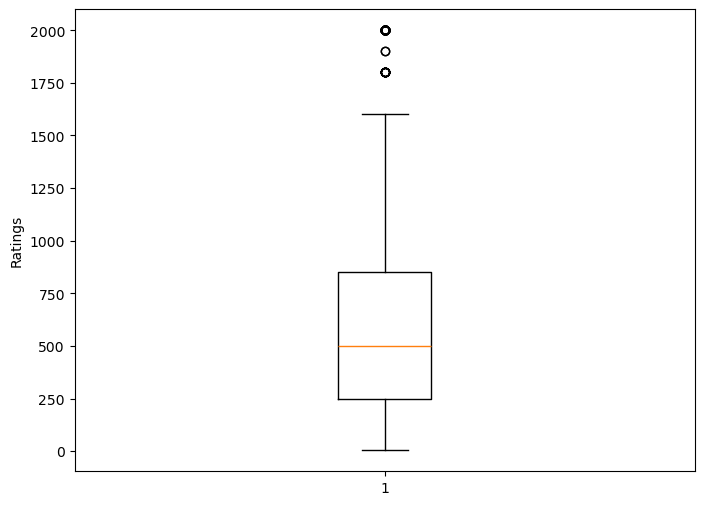

                                                   Name  \
0                                  Jade Luxury Banquets   
1                                      The Lalit Mumbai   
2                                Kumar Resort by TURTLE   
3               Whistling Woodzs Jungle Resort, Dandeli   
4     Fairfield by Marriott Mumbai International Air...   
...                                                 ...   
2364                                          RP Palace   
2365                        Hotel Maharaja Delight Lawn   
2366                                    Rajkamal Palace   
2367                                       Shivaay Lawn   
2368                                            PS Lawn   

               Venue_Categories Destination  Ratings  Reviews  Menu_price  \
0       Sea View Banquet & Lawn      Mumbai      5.0     12.0        3200   
1                  5 Star Hotel      Mumbai      4.9     16.0        3800   
2            Resort Near Mumbai      Mumbai      5.0      2.

In [14]:
print(numerical(data,"Capacity_max"))
print('-'*50)
print(iqr(data,'Capacity_max')) 

# `Observations`

**1. Histogram**
- Most of the 'Pax_max' values are clustered very close to zero, specifically in the first bar (between 0 and about 1,000).
- The bars get much, much smaller as the value of 'Pax_max' increases.

**2. KDE Plot**
-  The red line (representing the smoothed distribution of the data) has a very high, sharp peak right near zero.
-  It then drops off quickly and stays close to zero for all the higher values.

**3. Box plot(Before Handling Outliers)**
- The blue box, which shows the middle 50% of the data, is tiny and located very close to zero.
- The line inside the box (the median) is also near zero.
- There are many separate circles (dots) scattered far above the box, reaching up to 10,000.

 # Box plot(After handling outliers): 
`Observations`:
- The plot shows that after dealing with the extremely high values (outliers) from the previous dataset, the data is now much more concentrated and easier to read.
- **The middle 50% of the data** (the blue box) ranges roughly from 300 to 900.
- The **median** (the orange line inside the box) is around 500. This means half of the values are below 500 and half are above.
- The whiskers (the lines extending from the box) reach up to about **1,800** and down to **0**.
- There is still **one circle** at the very top, around **2,000,** which is now considered the new outlier after the previous, larger ones were removed.


## Rooms

min         1.000000
max       700.000000
mean       33.042634
median     20.000000
std        54.270884
skew        5.442395
Name: Rooms, dtype: float64

None
--------------------------------------------------
1264


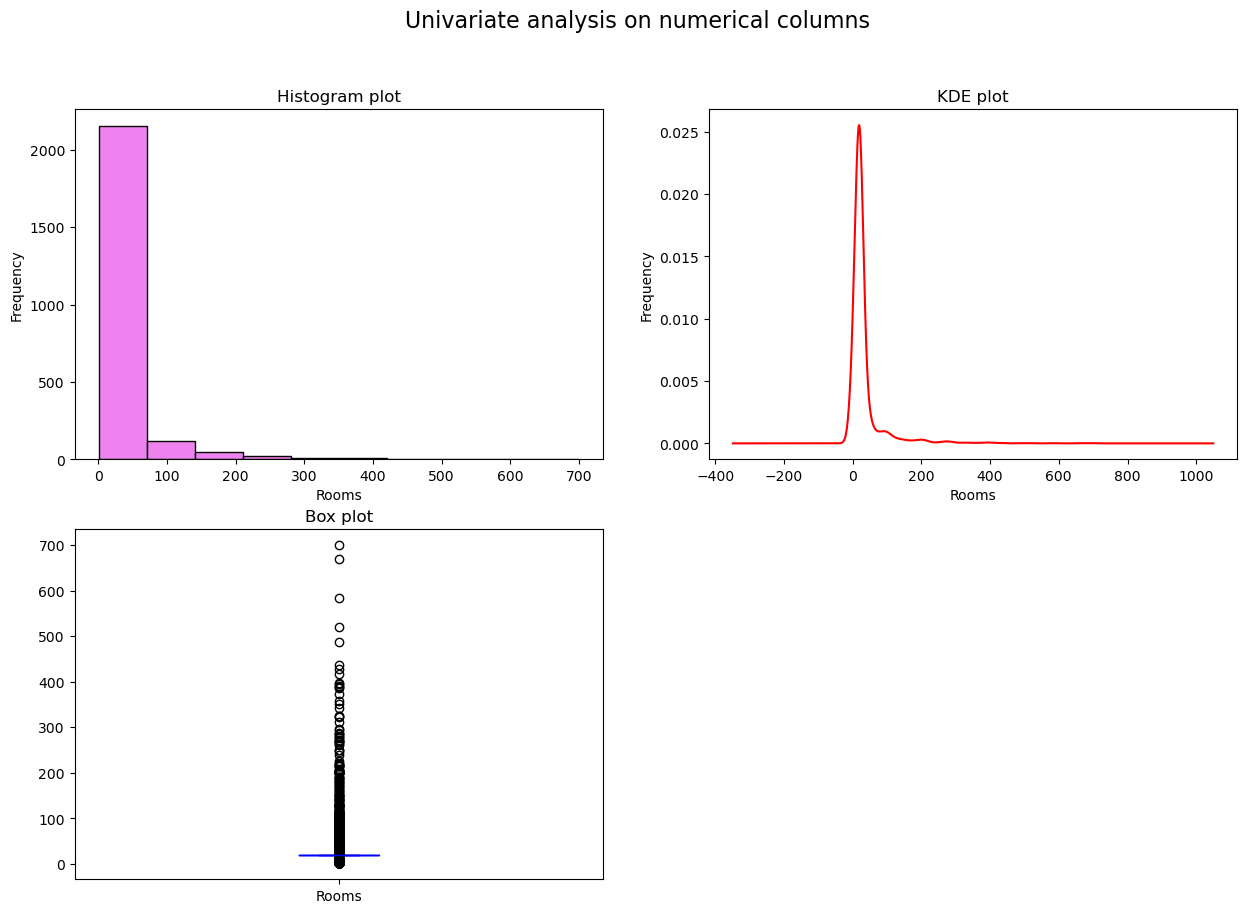

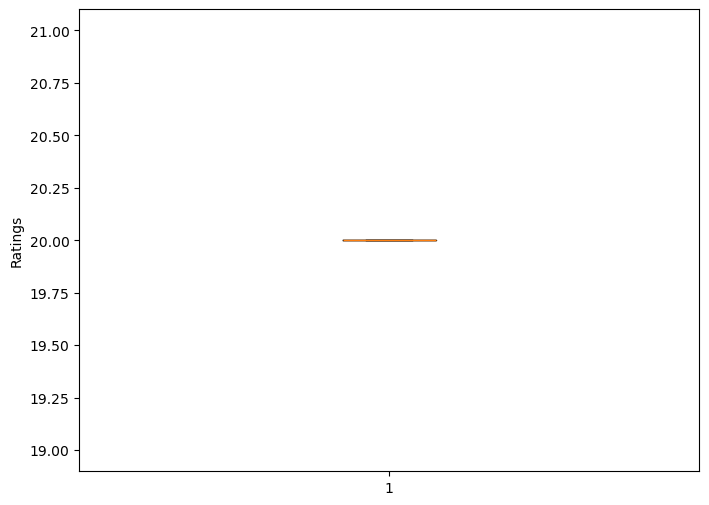

                             Name         Venue_Categories Destination  \
0            Jade Luxury Banquets  Sea View Banquet & Lawn      Mumbai   
5               Chandivali Studio             Wedding Lawn      Mumbai   
17    Vivette Banquets Malad West        Banquet with Lawn      Mumbai   
19                Blue Sea Mumbai  Sea View Banquet & Lawn      Mumbai   
24                    O2 Banquets             Banquet Hall      Mumbai   
...                           ...                      ...         ...   
2362        Shivgarh Country Club                   Resort     Lucknow   
2364                    RP Palace             Wedding Lawn     Lucknow   
2366              Rajkamal Palace      Banquet Hall & Lawn     Lucknow   
2367                 Shivaay Lawn             Wedding Lawn     Lucknow   
2368                      PS Lawn      Lawn & Banquet Hall     Lucknow   

      Ratings  Reviews  Menu_price  Capacity_min  Capacity_max  Rooms  \
0         5.0     12.0        3200    

In [15]:
print(numerical(data,'Rooms'))
print('-'*50)
print(iqr(data,'Rooms')) 

# `Observations`

**1. Histogram**
- The vast majority of 'Rooms' values are squeezed into the very first bar, which is close to zero (likely between 0 and 50).
- All the bars for higher room counts are extremely short, indicating very few instances with that many rooms.

**2. KDE plot**
- The red line (the smoothed distribution) shows a **very high, sharp spike** right at zero.
- The line immediately drops to almost nothing and stays flat for all higher 'Rooms' values.

**3. Box plot(Before Handling Outliers)**
- The blue box, which represents the middle 50% of the data, is **incredibly small** and sits directly on the zero line.
- The median line is also at or near zero.
- There is a **huge vertical scatter of circles (dots)** extending all the way up to around 600.

# Univariate Analysis

## Categorical 

In [16]:
def categorical(data, column_name):
    if column_name in data:
        data[column_name].agg(['count','unique'])
        plt.figure(figsize=(18,15))
        ##barh plo
        plt.subplot(1,2,1)
        category_count= data[column_name].value_counts()
        category_count.head(10).plot(kind = "bar",color = sns.color_palette('magma'))
        plt.title("Top 10 Venue Categories")
        plt.xlabel("Count")
        plt.ylabel(column_name)
        plt.tight_layout()
        ##pie
        plt.subplot(1,2,2)
        category_count= data[column_name].value_counts()
        category_count.head(10).plot(kind= 'pie', autopct="%1.1f%%",pctdistance=0.8,labeldistance=1.1,)
        plt.legend(loc="center right", bbox_to_anchor=(1, 0, 0.5, 1))
        plt.title("Pie Chart")
        plt.tight_layout()
        plt.savefig(f"{column_name}_plots.png") 

# venue Cteogories

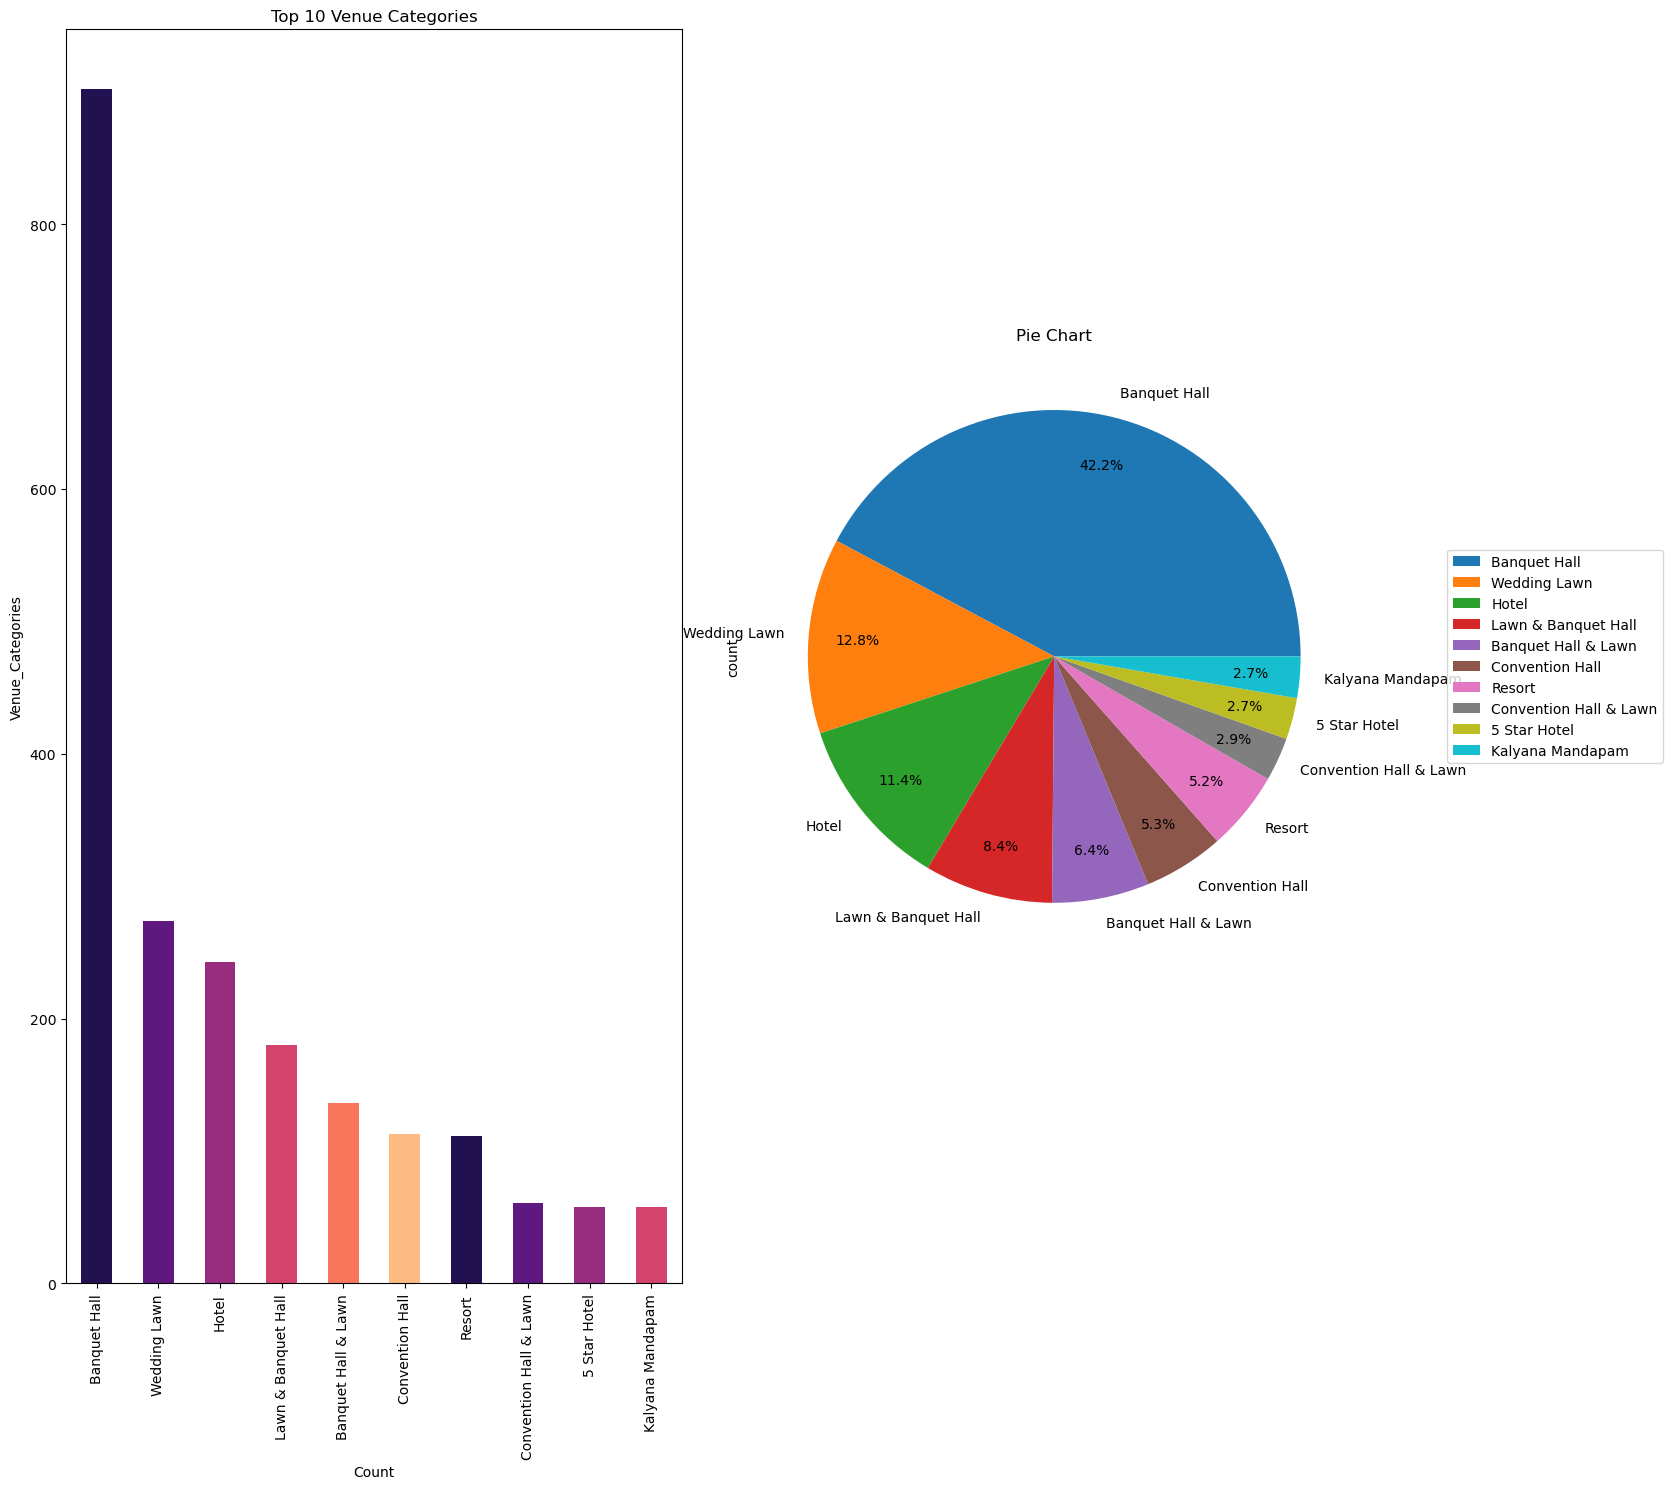

In [17]:
categorical(data, 'Venue_Categories')

# `Observations`
**1. Bar Chart**
- **Banquet Halls are overwhelmingly the most common venue type**. They have a significantly higher count (over 800) than any other category.
- The popularity drops sharply after the first category. The second most popular, **Wedding Lawn**, has a count of just over 300.
- **Hotel** venues are also very popular, closely following Wedding Lawns.
- As you move down the list, the venue categories become much less frequent. The 10th category, **Kalyana Mandapam**, has a count under 100.
- **The top four venue types (Banquet Hall, Wedding Lawn, Hotel, and Lawn & Banquet Hall)** are clearly the dominant choices, with the rest having much lower numbers.

**2. Pie Chart**
- **Banquet Hall** makes up the largest slice, representing **38.6%** of all the venues shown. This confirms the bar graph's finding.
- The next two largest shares are **Wedding Lawn at 14.5%** and Hotel at 11.3%.
- Together, the top three categories **(Banquet Hall, Wedding Lawn, and Hotel)** account for over **64%** (38.6 + 14.5 + 11.3) of all venues.
- All the remaining seven categories combined only make up about **35.6%** of the total.
- Venue types like **Kalyana Mandapam, 5 Star Hotel, and Convention Hall & Lawn** are the least represented, each making up a very small percentage (around 3% or less).

# Destination

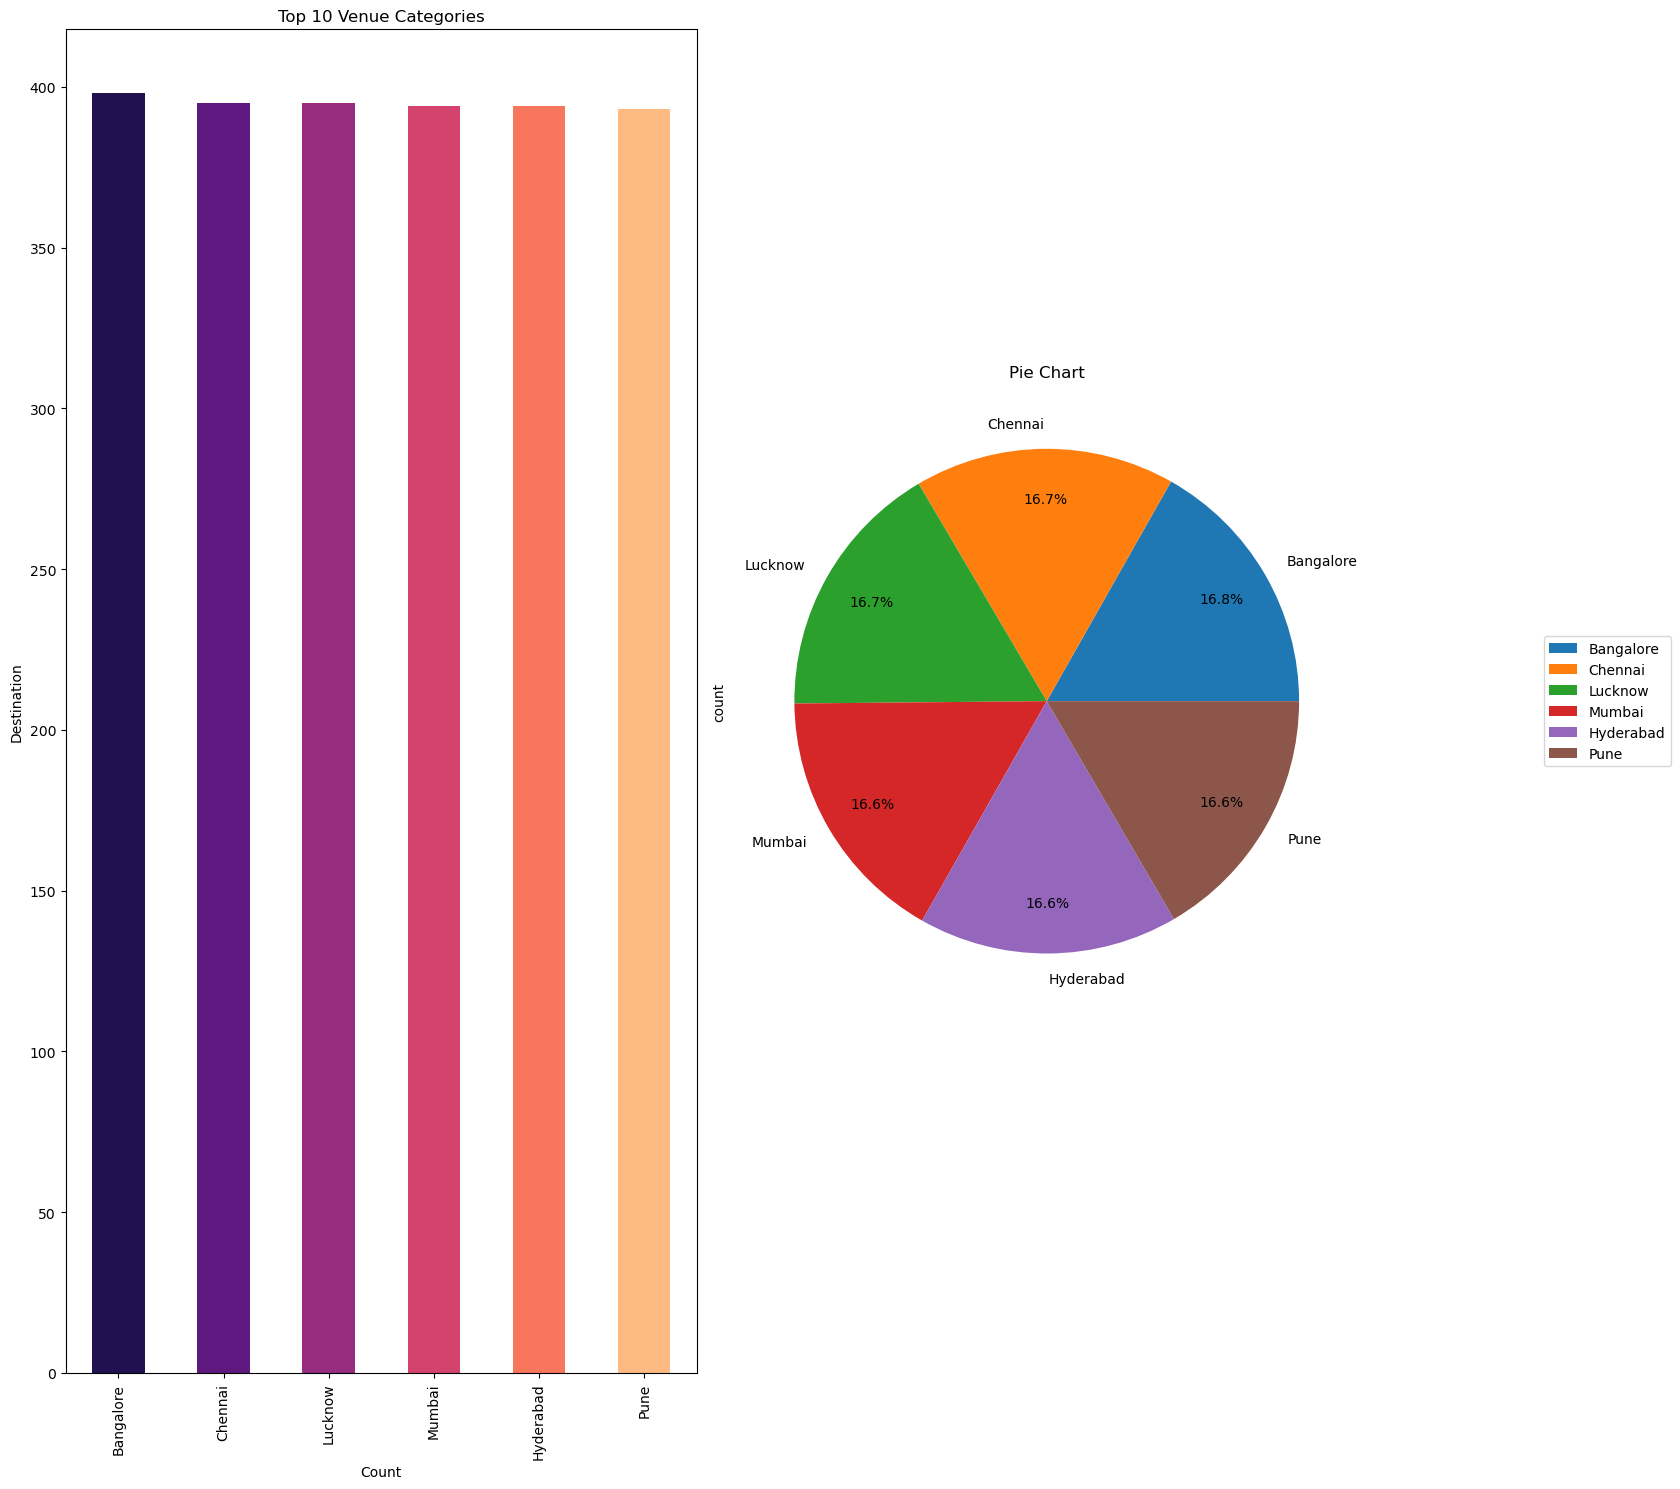

In [18]:
categorical(data, 'Destination')

# `Observations`
**1. Bar Chart**
- **All six cities have a very similar count of venues.** The bars are almost exactly the same height, hovering just below 400.
- **Mumbai** appears to have the highest count, but only slightly more than the others.
- **Hyderabad** appears to have the lowest count, but again, the difference is minimal.
- There is no single city that stands out as having significantly more or fewer venues than the others.

**2. Pie Chart**
- The chart is divided into **six nearly equal slices.**
- **Mumbai** has the largest percentage at 16.9%, but it's only slightly ahead.
- Pune and Bangalore are tied for the next largest share at 16.8%.
- **Lucknow** has the smallest slice at 16.6%, which is still very close to the rest.
- The difference between the highest percentage (16.9% for Mumbai) and the lowest (16.6% for Lucknow) is less than half a percent (0.3%).

# **Bivariate Vizual Analysis:**


1.   Numerical vs Numerical
2.   Categorical vs Categorical
3.   Numerical vs Categorical

**1. Numerical vs Numerical:**  

      *   Scatter Plot
      *   Joint Plot

**2. Categorica vs Categorical:**

      *   Count Plot

**3. Numerical vs Categorical:**



      *   Bar Plot
      *   Box Plot
      *   Violin Plot
      *   Displot

In [19]:
print(numerical_columns)
print('-'*50)
print(categorical_columns)

['Ratings', 'Reviews', 'Menu_price', 'Capacity_min', 'Capacity_max', 'Rooms', 'Amenties_more']
--------------------------------------------------
['Name', 'Venue_Categories', 'Destination']


In [20]:
def num_num(df, col1, col2):
    ##plot
    plt.figure(figsize= (15,15))
    plt.subplot(2,2,1)
    ## scatter plot
    sns.scatterplot(data=df, x= col1, y=col2)
    plt.title('Scatterplot')
    print()
    #plt.xticks(rotation= 45)
    ## line plot
    plt.subplot(2,2,2)
    sns.lineplot(data= df, x= col1, y=col2)
    plt.title('Lineplot')
    plt.savefig("Bivariate analysis on numerical column.png")
    print()
    ## joint plot
    sns.jointplot(data=df, y= col1, x= col2,kind="hist")
    plt.title('Jointplot')
    plt.savefig("Jointplot.png")
    print()

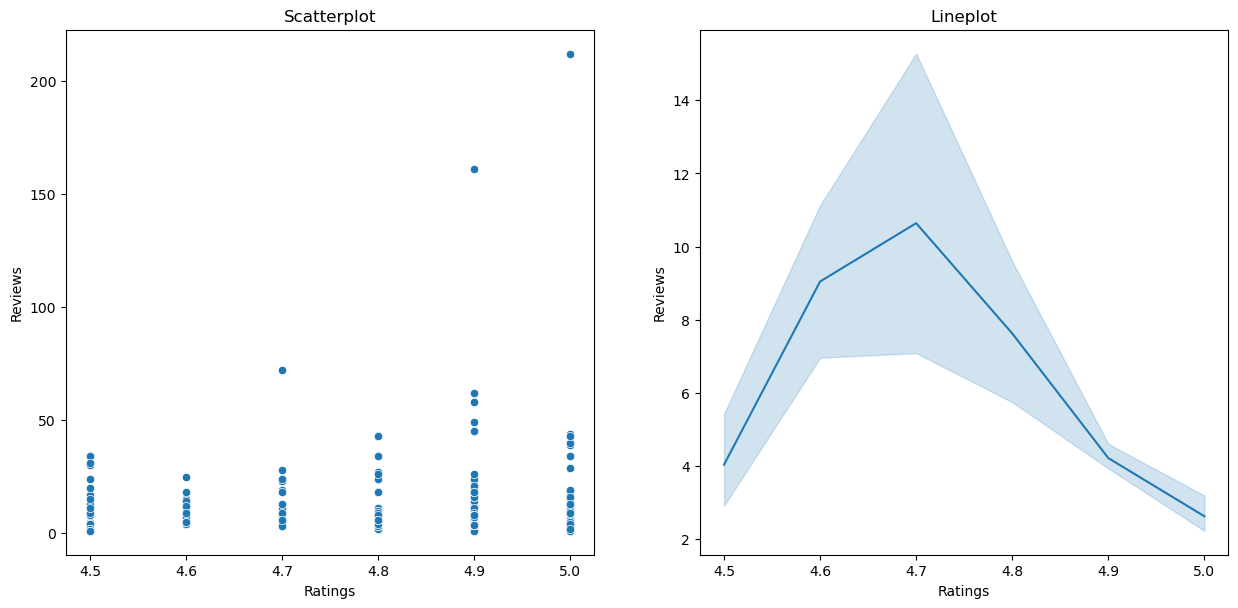

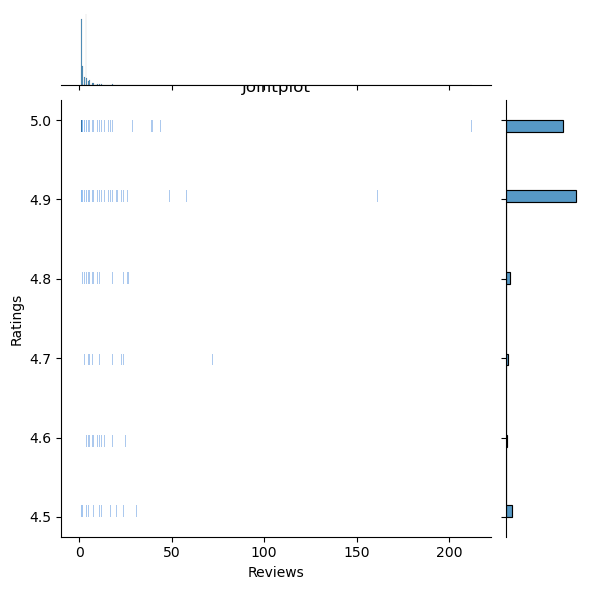

In [21]:
num_num(data,'Ratings','Reviews')

# `Observations`
**1. Scatter Plot**
- The scatterplot shows that as the ratings increase (from 4.5 to 5.0), the number of reviews varies widely — some highly rated items have many reviews, while others have very few.

**2. Line Plot**
- The lineplot shows a peak around a rating of 4.6, where the average number of reviews is highest, and then it gradually decreases as ratings approach 5.0.

**3. Joint Plot**
- Most of the products have very high ratings — around 4.9 and 5.0.
- The number of reviews is generally low, but a few products have a very large number of reviews.
- The bars on the sides show that 4.9 and 5.0 ratings are the most common.

# Cat v/s num

In [23]:
def cat_num(dataframe, categorical, numerical_columns, head_value= 10):
    if head_value:
        top_categories = dataframe[categorical].value_counts(normalize= True).head(10).index.tolist()
        dataframe = dataframe[dataframe[categorical].isin(top_categories)]
        #loop over numerical columns
    for num in numerical_columns:
        group_data= dataframe.groupby(categorical)[num].agg(['mean','median','min','max'])
        print(group_data)
        ##plot
        plt.figure(figsize= (15,15))
        plt.subplot(2,2,1)
        #bar plot
        sns.barplot(data= dataframe,y=categorical, x= num,palette="magma")
        plt.title('Bar plot')
        plt.tight_layout()
        #box plot
        plt.subplot(2,2,2)
        sns.boxplot(y=categorical,x= num, data= dataframe)
        plt.title('BOX plot')
        plt.tight_layout()
        ## violin plot
        plt.subplot(2,2,3)
        sns.violinplot(y=categorical, x= num, data= dataframe)
        plt.title('Violin Plot')
        plt.tight_layout()
        ##scatter plot
        plt.subplot(2,2,4)
        sns.scatterplot(x=categorical, y= num,data= dataframe )
        plt.title('Scatterplot')
        plt.xticks(rotation= 45)
        plt.tight_layout()
        filename = f"{categorical}_vs_{num}.png"
        plt.savefig(filename)
        print(f"Saved plot: {filename}")
        plt.show()

                            mean  median  min  max
Venue_Categories                                  
5 Star Hotel            4.856897     4.9  4.5  5.0
Banquet Hall            4.919623     4.9  4.5  5.0
Banquet Hall & Lawn     4.911029     4.9  4.5  5.0
Convention Hall         4.917699     5.0  4.5  5.0
Convention Hall & Lawn  4.927869     5.0  4.5  5.0
Hotel                   4.911934     4.9  4.5  5.0
Kalyana Mandapam        4.931034     5.0  4.5  5.0
Lawn & Banquet Hall     4.925556     4.9  4.5  5.0
Resort                  4.905405     4.9  4.5  5.0
Wedding Lawn            4.909489     4.9  4.5  5.0


C:\Users\HP\AppData\Local\Temp\ipykernel_15556\2015034743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= dataframe,y=categorical, x= num,palette="magma")


Saved plot: Venue_Categories_vs_Ratings.png


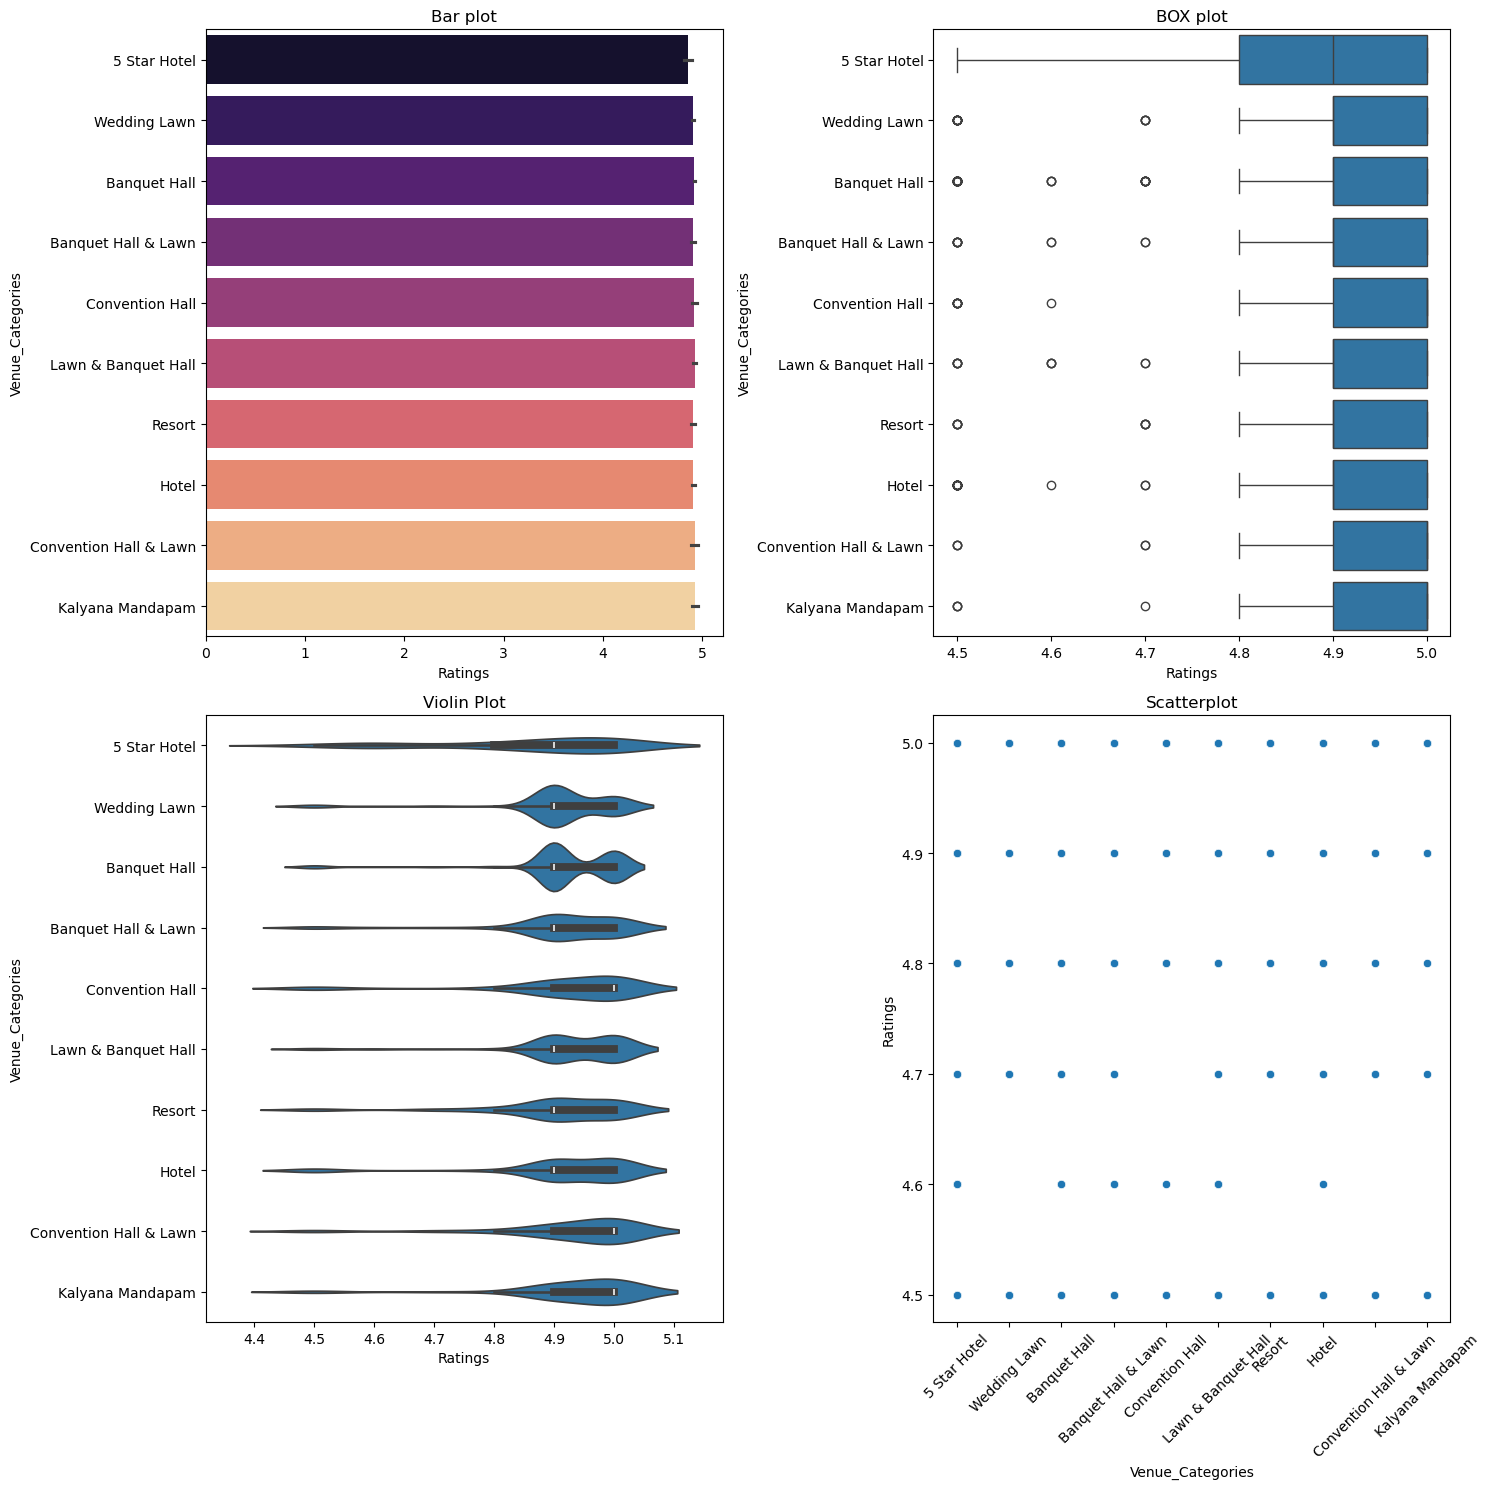

                            mean  median  min    max
Venue_Categories                                    
5 Star Hotel            7.513793     6.0  1.0   28.0
Banquet Hall            3.262084     3.8  1.0  161.0
Banquet Hall & Lawn     4.297059     3.8  1.0   34.0
Convention Hall         2.677876     2.0  1.0   27.0
Convention Hall & Lawn  3.806557     2.0  1.0   26.0
Hotel                   3.138272     3.0  1.0   21.0
Kalyana Mandapam        1.951724     1.0  1.0    3.8
Lawn & Banquet Hall     3.533333     3.4  1.0   49.0
Resort                  4.277477     3.8  1.0   27.0
Wedding Lawn            3.405839     3.8  1.0   62.0


C:\Users\HP\AppData\Local\Temp\ipykernel_15556\2015034743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= dataframe,y=categorical, x= num,palette="magma")


Saved plot: Venue_Categories_vs_Reviews.png


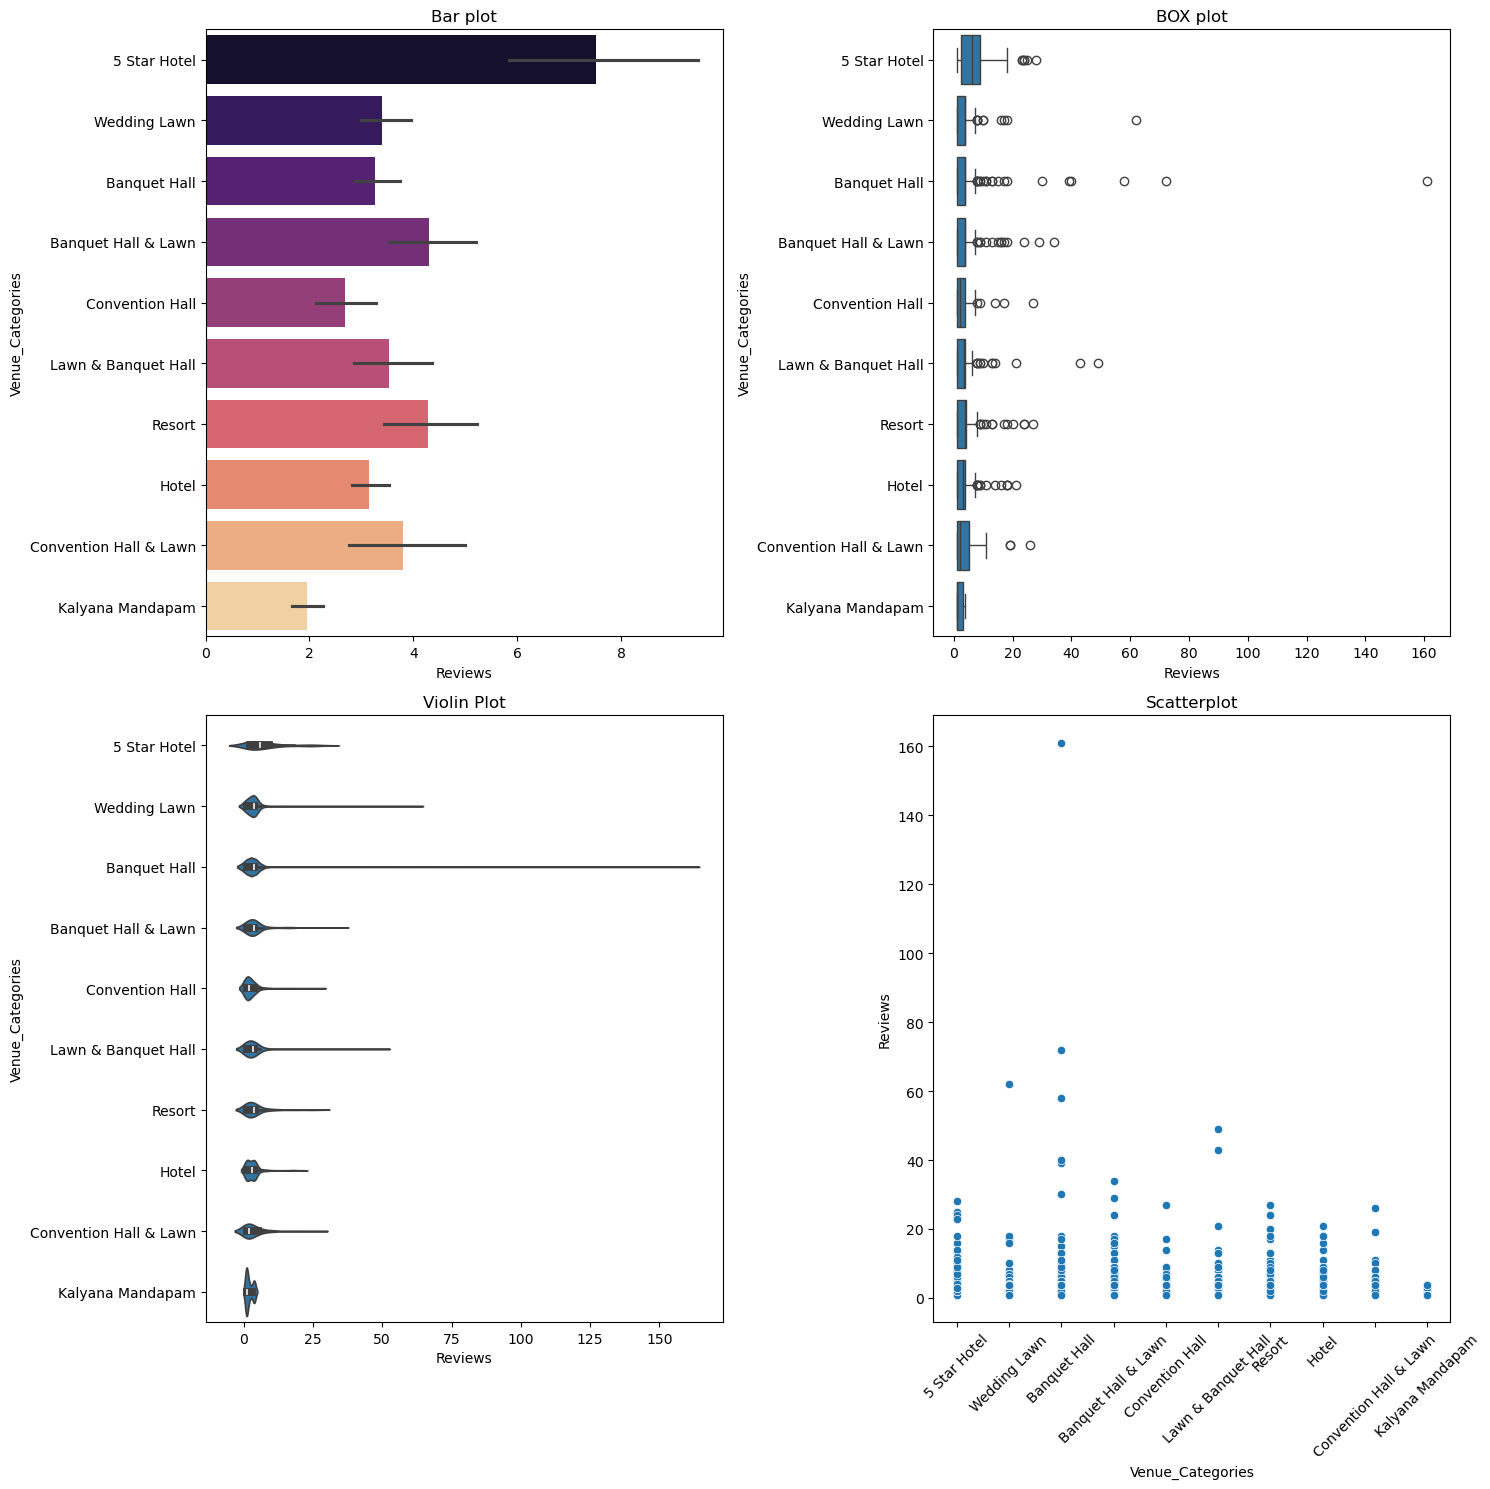

                                mean  median  min      max
Venue_Categories                                          
5 Star Hotel             2318.086207  2350.0  650     5500
Banquet Hall             4555.290466   600.0   23   245000
Banquet Hall & Lawn     23932.220588   650.0  150   500000
Convention Hall         27056.398230   550.0  200   650000
Convention Hall & Lawn  96655.131148   650.0  220  2000000
Hotel                   12484.222222   700.0  150  1400000
Kalyana Mandapam        14313.793103   500.0  200   450000
Lawn & Banquet Hall     17575.288889   650.0  175   300000
Resort                  25012.864865   800.0  200   650000
Wedding Lawn            20522.062044   650.0  150   375000


C:\Users\HP\AppData\Local\Temp\ipykernel_15556\2015034743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= dataframe,y=categorical, x= num,palette="magma")


Saved plot: Venue_Categories_vs_Menu_price.png


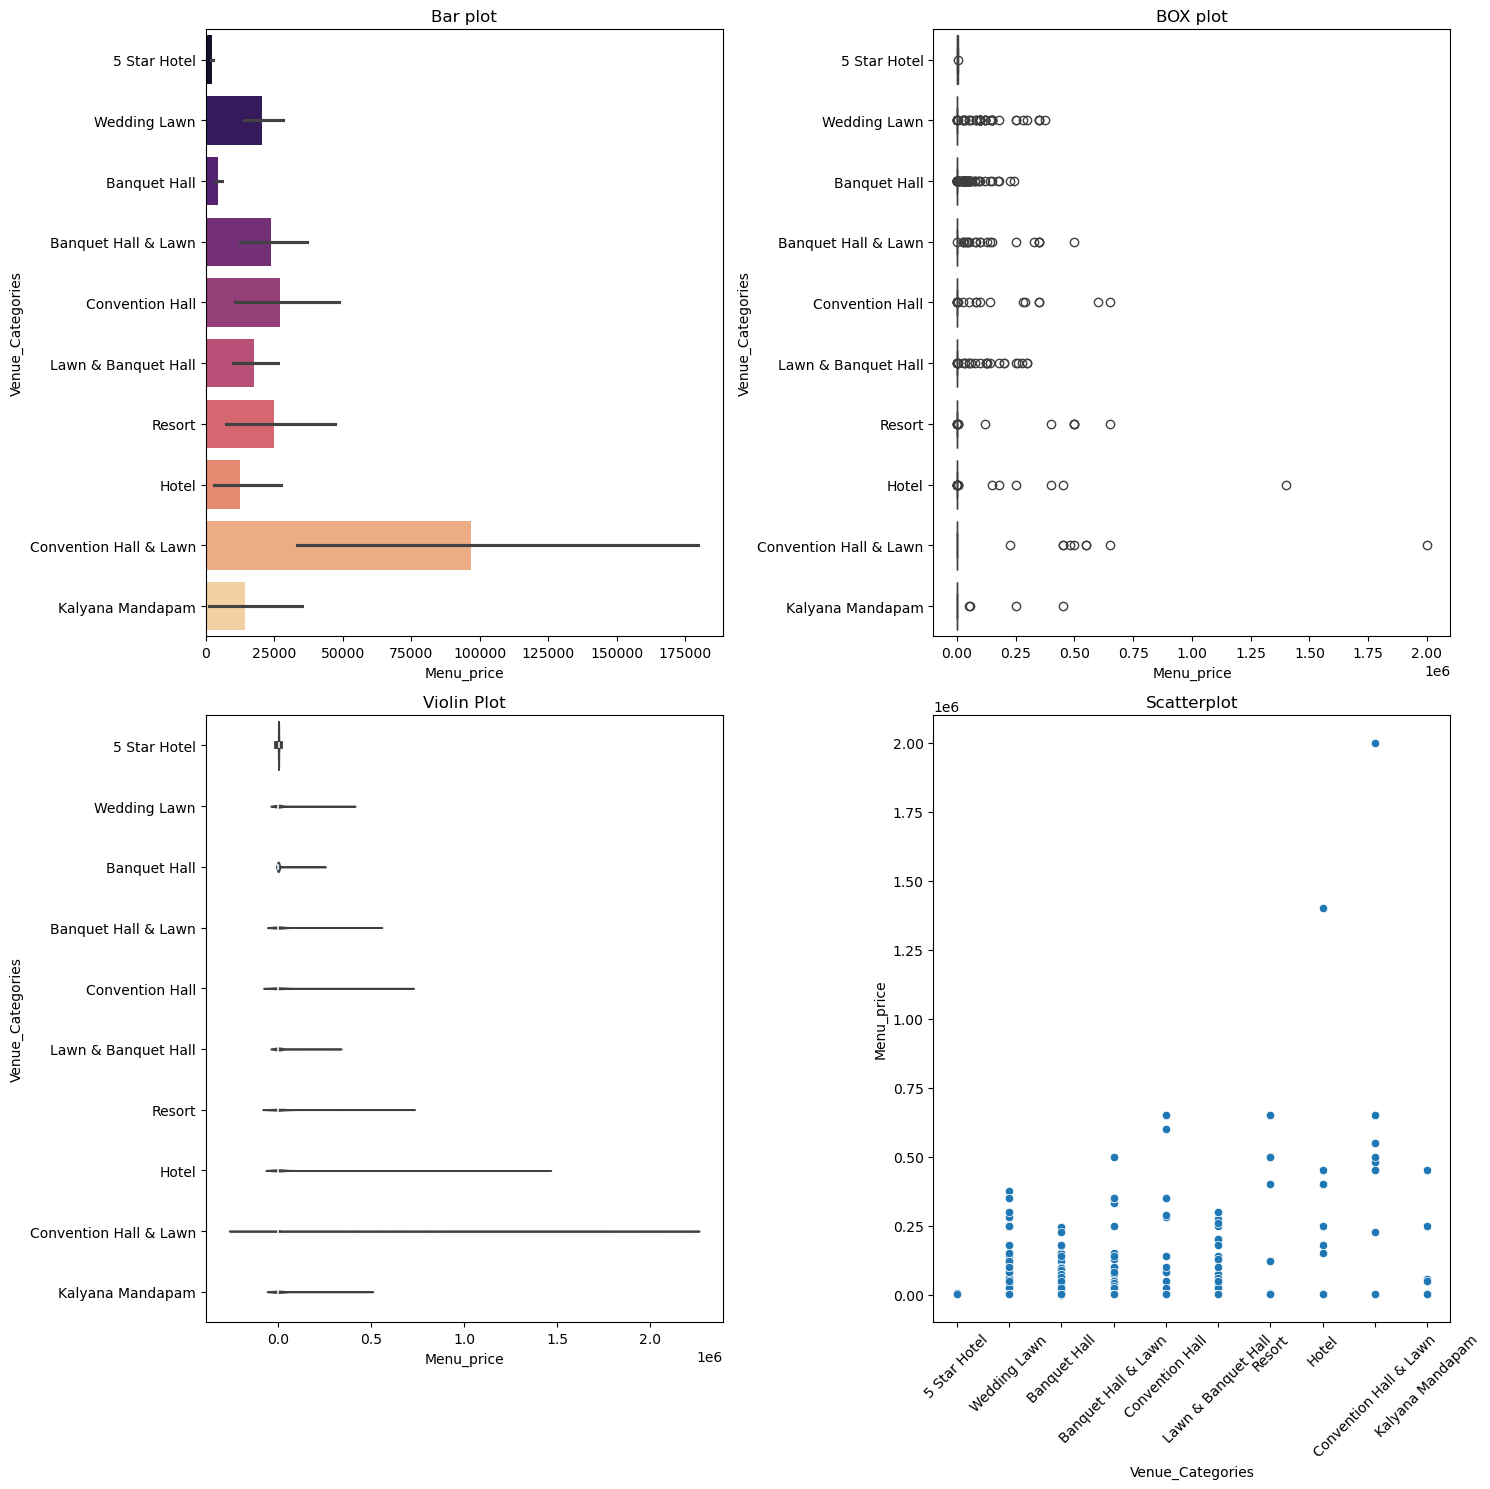

                              mean  median  min   max
Venue_Categories                                     
5 Star Hotel            177.362069   100.0    8   900
Banquet Hall            254.356984   200.0   10  2400
Banquet Hall & Lawn     306.948529   200.0   30  2200
Convention Hall         760.929204   700.0   50  2800
Convention Hall & Lawn  611.311475   500.0   30  3000
Hotel                   171.415638   100.0    8  2000
Kalyana Mandapam        499.568966   400.0  120  1200
Lawn & Banquet Hall     250.888889   200.0   20  1500
Resort                  289.549550   150.0   15  2500
Wedding Lawn            584.040146   400.0   10  6000


C:\Users\HP\AppData\Local\Temp\ipykernel_15556\2015034743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= dataframe,y=categorical, x= num,palette="magma")


Saved plot: Venue_Categories_vs_Capacity_min.png


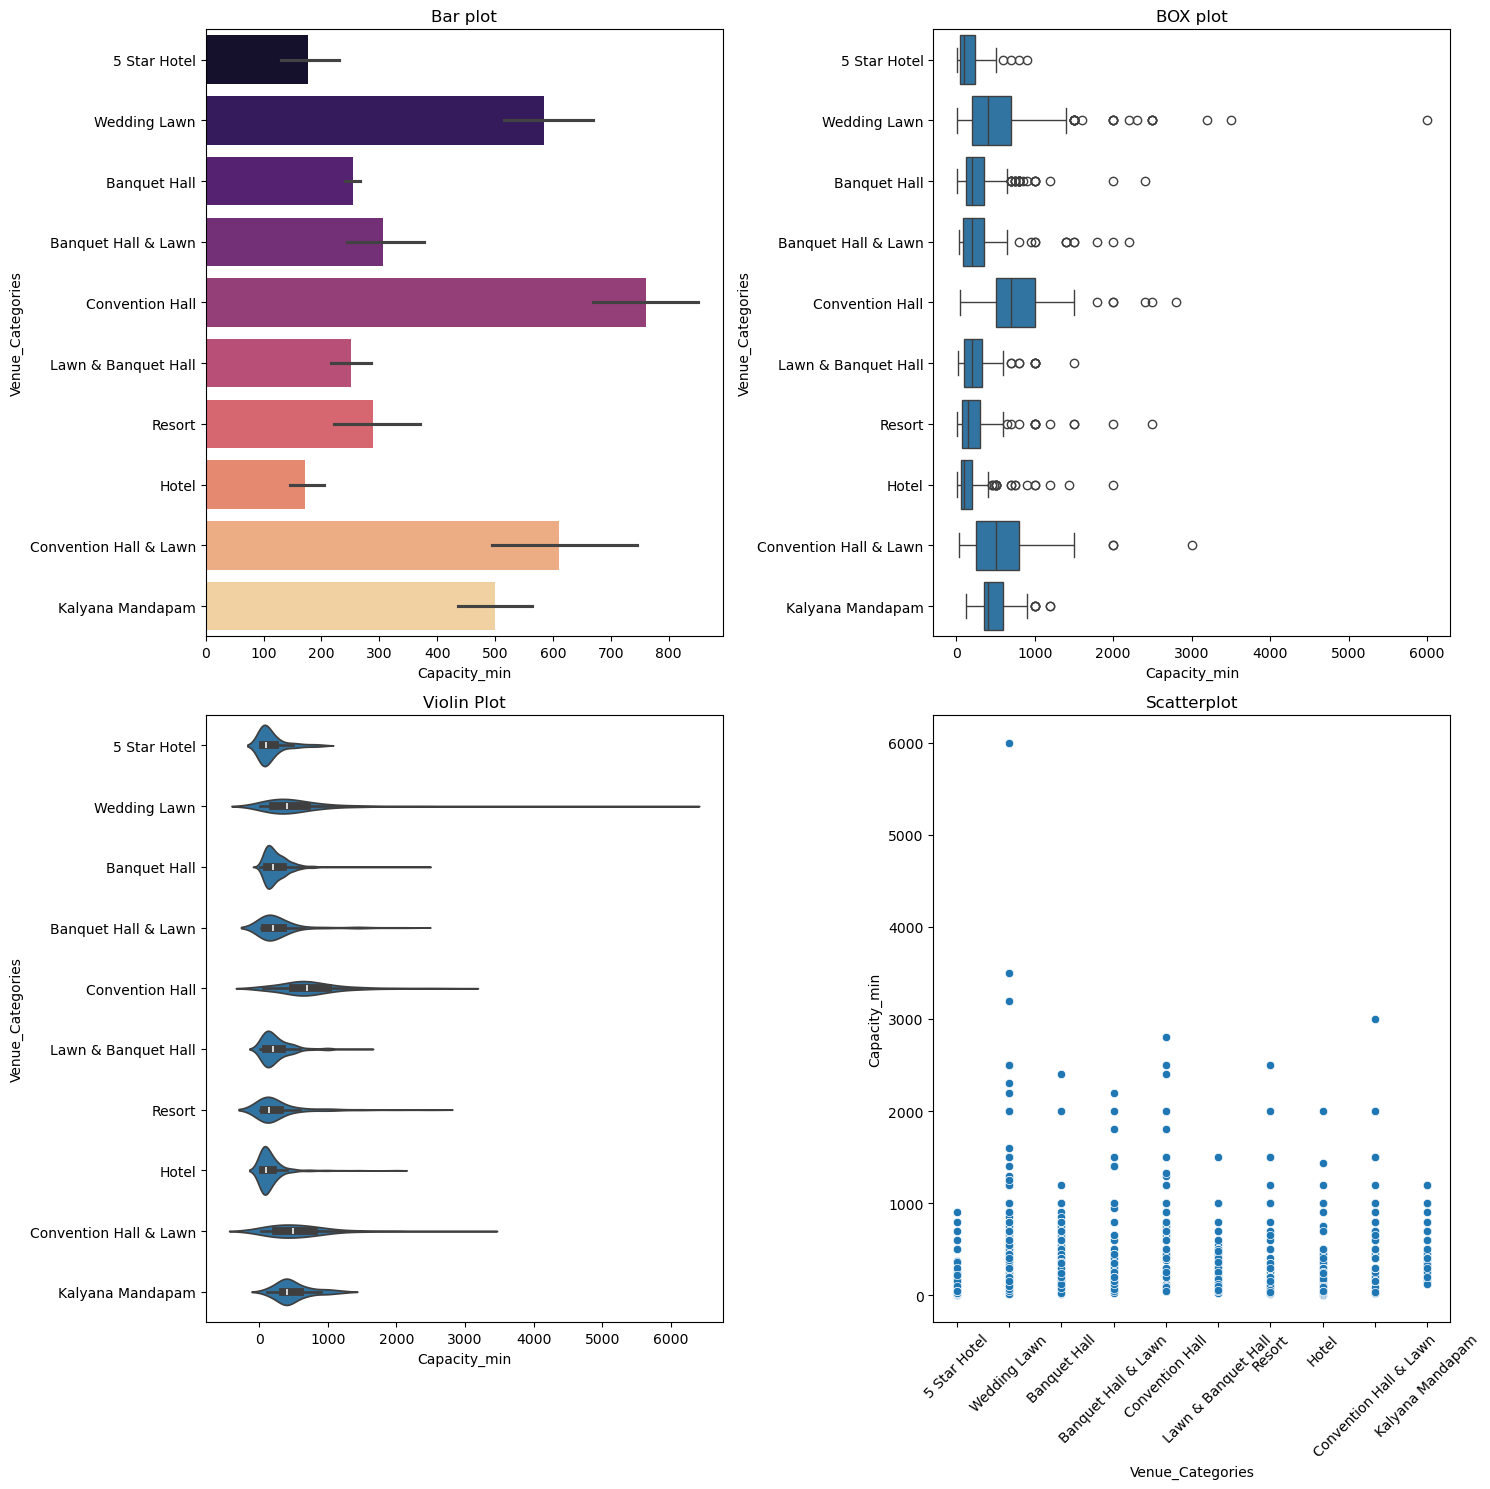

                               mean  median  min    max
Venue_Categories                                       
5 Star Hotel             889.137931   625.0   50   4000
Banquet Hall             453.381375   400.0   70   4000
Banquet Hall & Lawn      886.102941   600.0   70   6000
Convention Hall         1391.150442  1100.0  500   7000
Convention Hall & Lawn  2336.885246  1500.0  700  10000
Hotel                    554.979424   350.0   50   4000
Kalyana Mandapam         812.068966   600.0  150   3000
Lawn & Banquet Hall     1189.138889   800.0  100  12000
Resort                  1449.549550  1000.0  100   7500
Wedding Lawn             940.507299   700.0    4   7000


C:\Users\HP\AppData\Local\Temp\ipykernel_15556\2015034743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= dataframe,y=categorical, x= num,palette="magma")


Saved plot: Venue_Categories_vs_Capacity_max.png


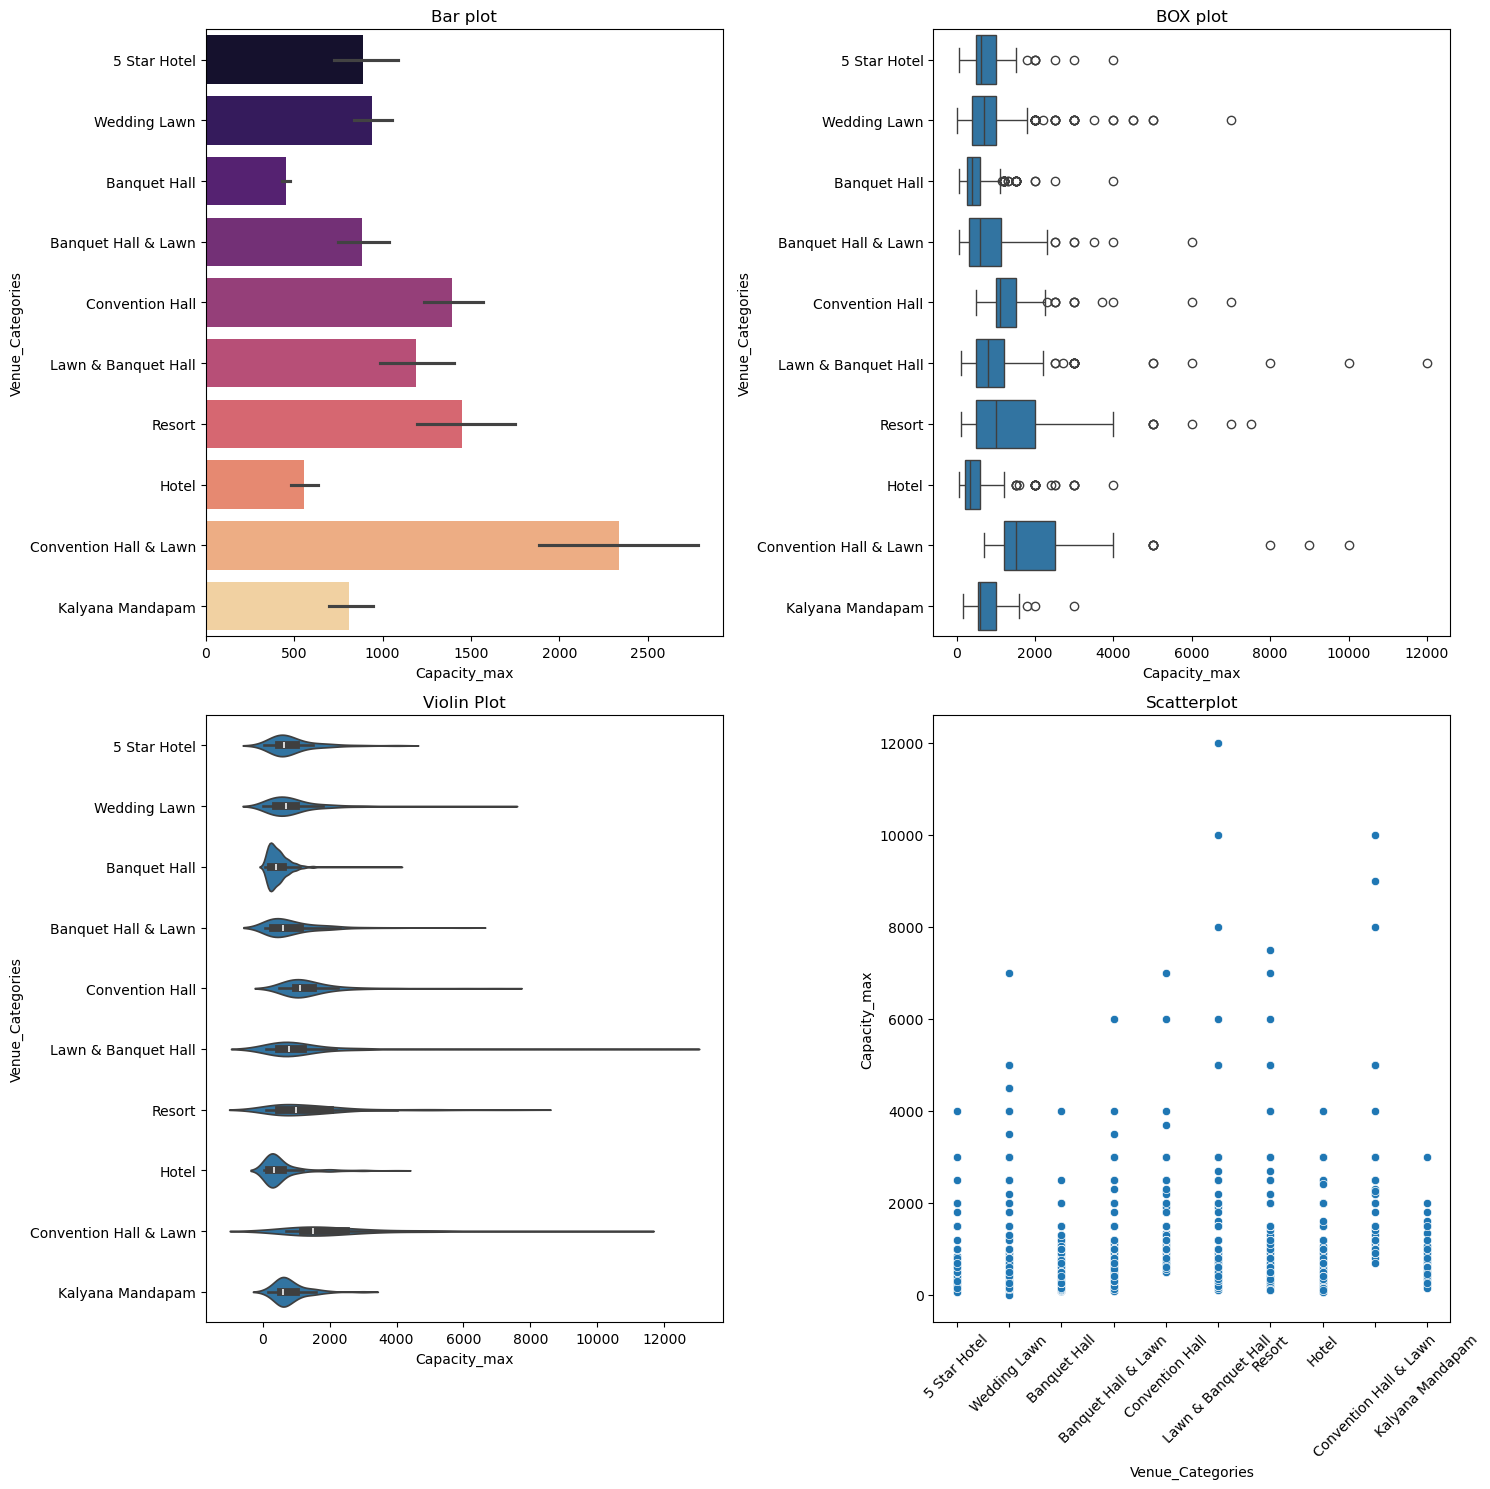

                              mean  median  min  max
Venue_Categories                                    
5 Star Hotel            232.500000   202.0   41  583
Banquet Hall             17.751663    20.0    1   88
Banquet Hall & Lawn      16.279412    20.0    1   54
Convention Hall          18.088496    20.0    2   75
Convention Hall & Lawn   15.196721    20.0    2   20
Hotel                    63.316872    45.0   11  669
Kalyana Mandapam         19.206897    20.0    8   20
Lawn & Banquet Hall      16.266667    20.0    1   24
Resort                   44.675676    30.0   14  250
Wedding Lawn             14.536496    20.0    1   28


C:\Users\HP\AppData\Local\Temp\ipykernel_15556\2015034743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= dataframe,y=categorical, x= num,palette="magma")


Saved plot: Venue_Categories_vs_Rooms.png


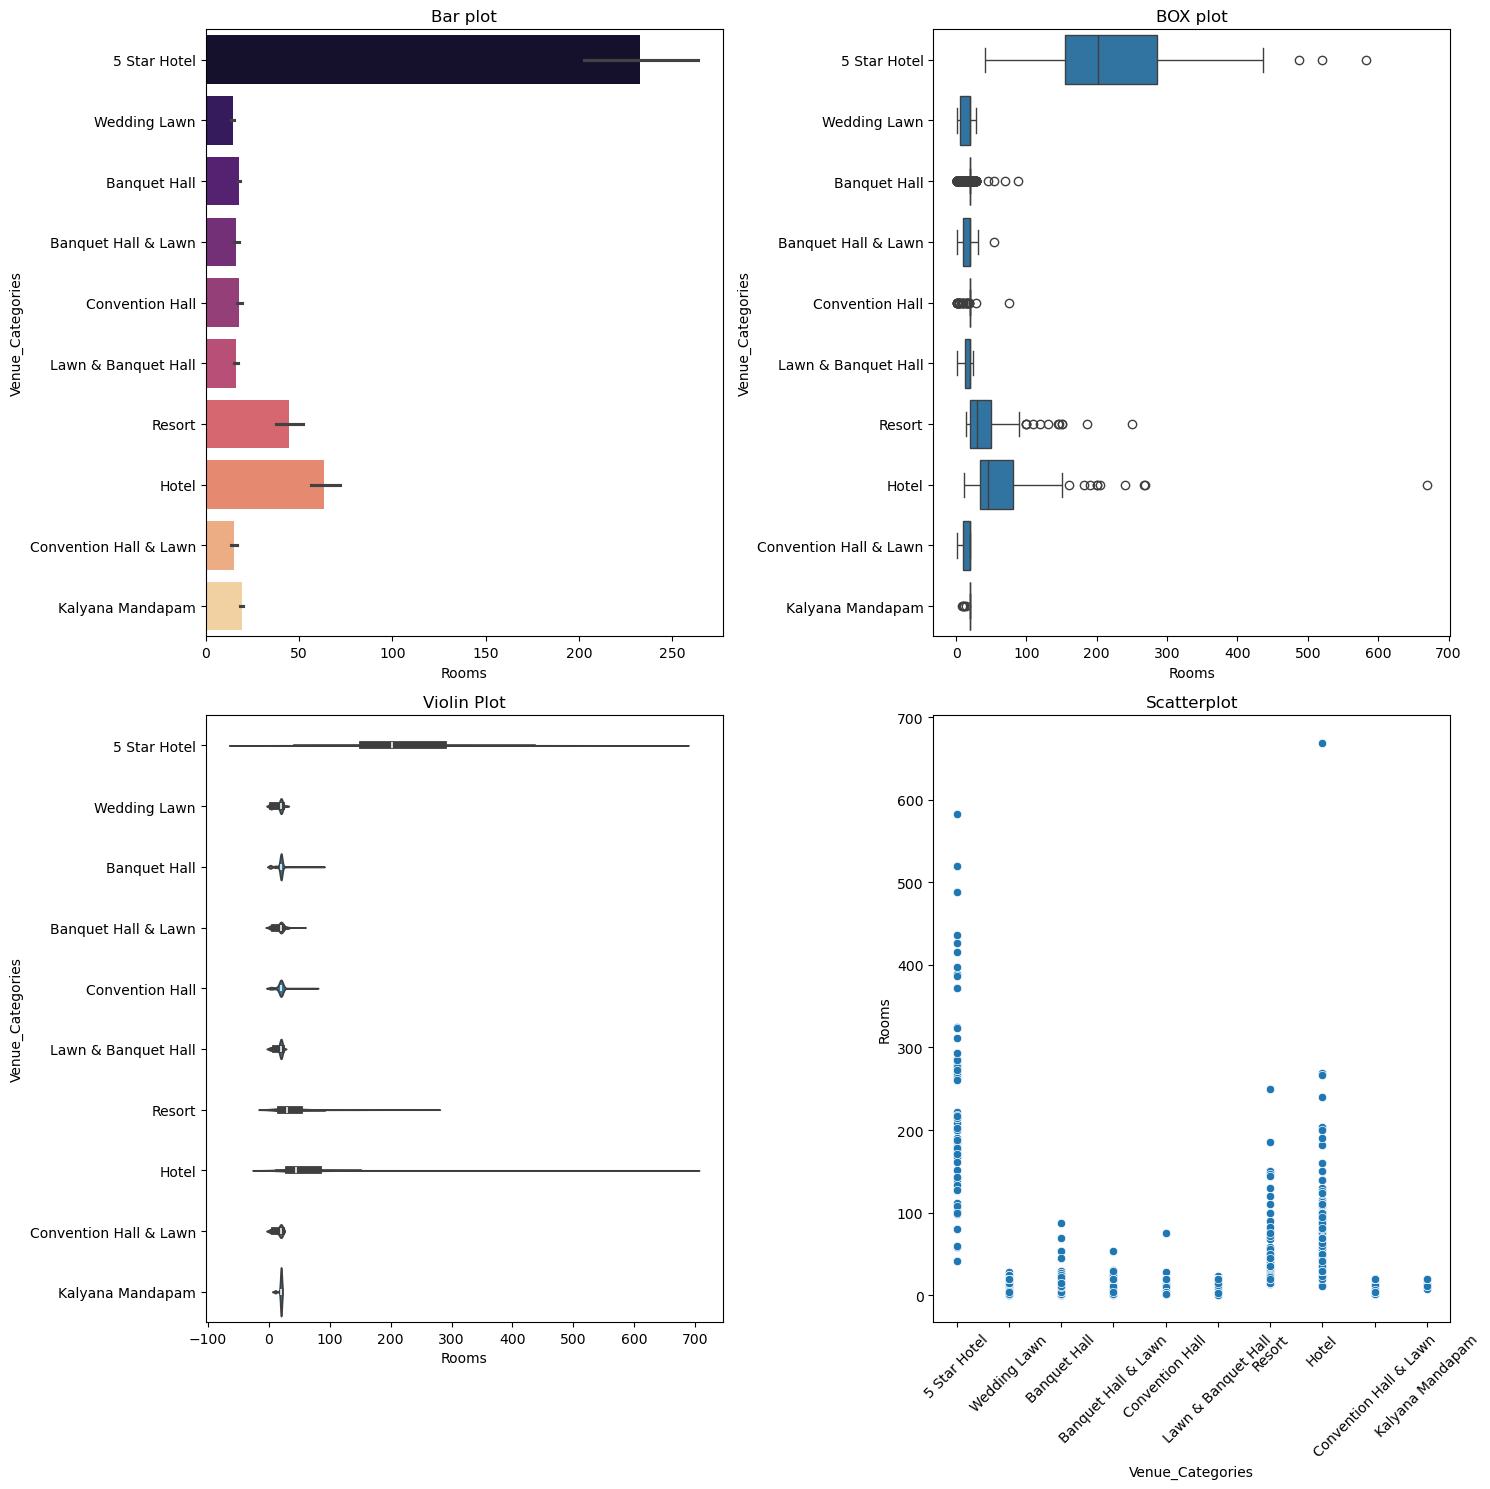

                            mean  median  min  max
Venue_Categories                                  
5 Star Hotel            3.155172     3.0    3    4
Banquet Hall            2.474501     2.0    2    6
Banquet Hall & Lawn     2.889706     3.0    1    7
Convention Hall         2.495575     2.0    2    8
Convention Hall & Lawn  2.819672     3.0    2    5
Hotel                   3.082305     3.0    2    4
Kalyana Mandapam        2.241379     2.0    2    4
Lawn & Banquet Hall     2.622222     2.0    2    6
Resort                  3.279279     3.0    2    6
Wedding Lawn            2.715328     3.0    2    6


C:\Users\HP\AppData\Local\Temp\ipykernel_15556\2015034743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= dataframe,y=categorical, x= num,palette="magma")


Saved plot: Venue_Categories_vs_Amenties_more.png


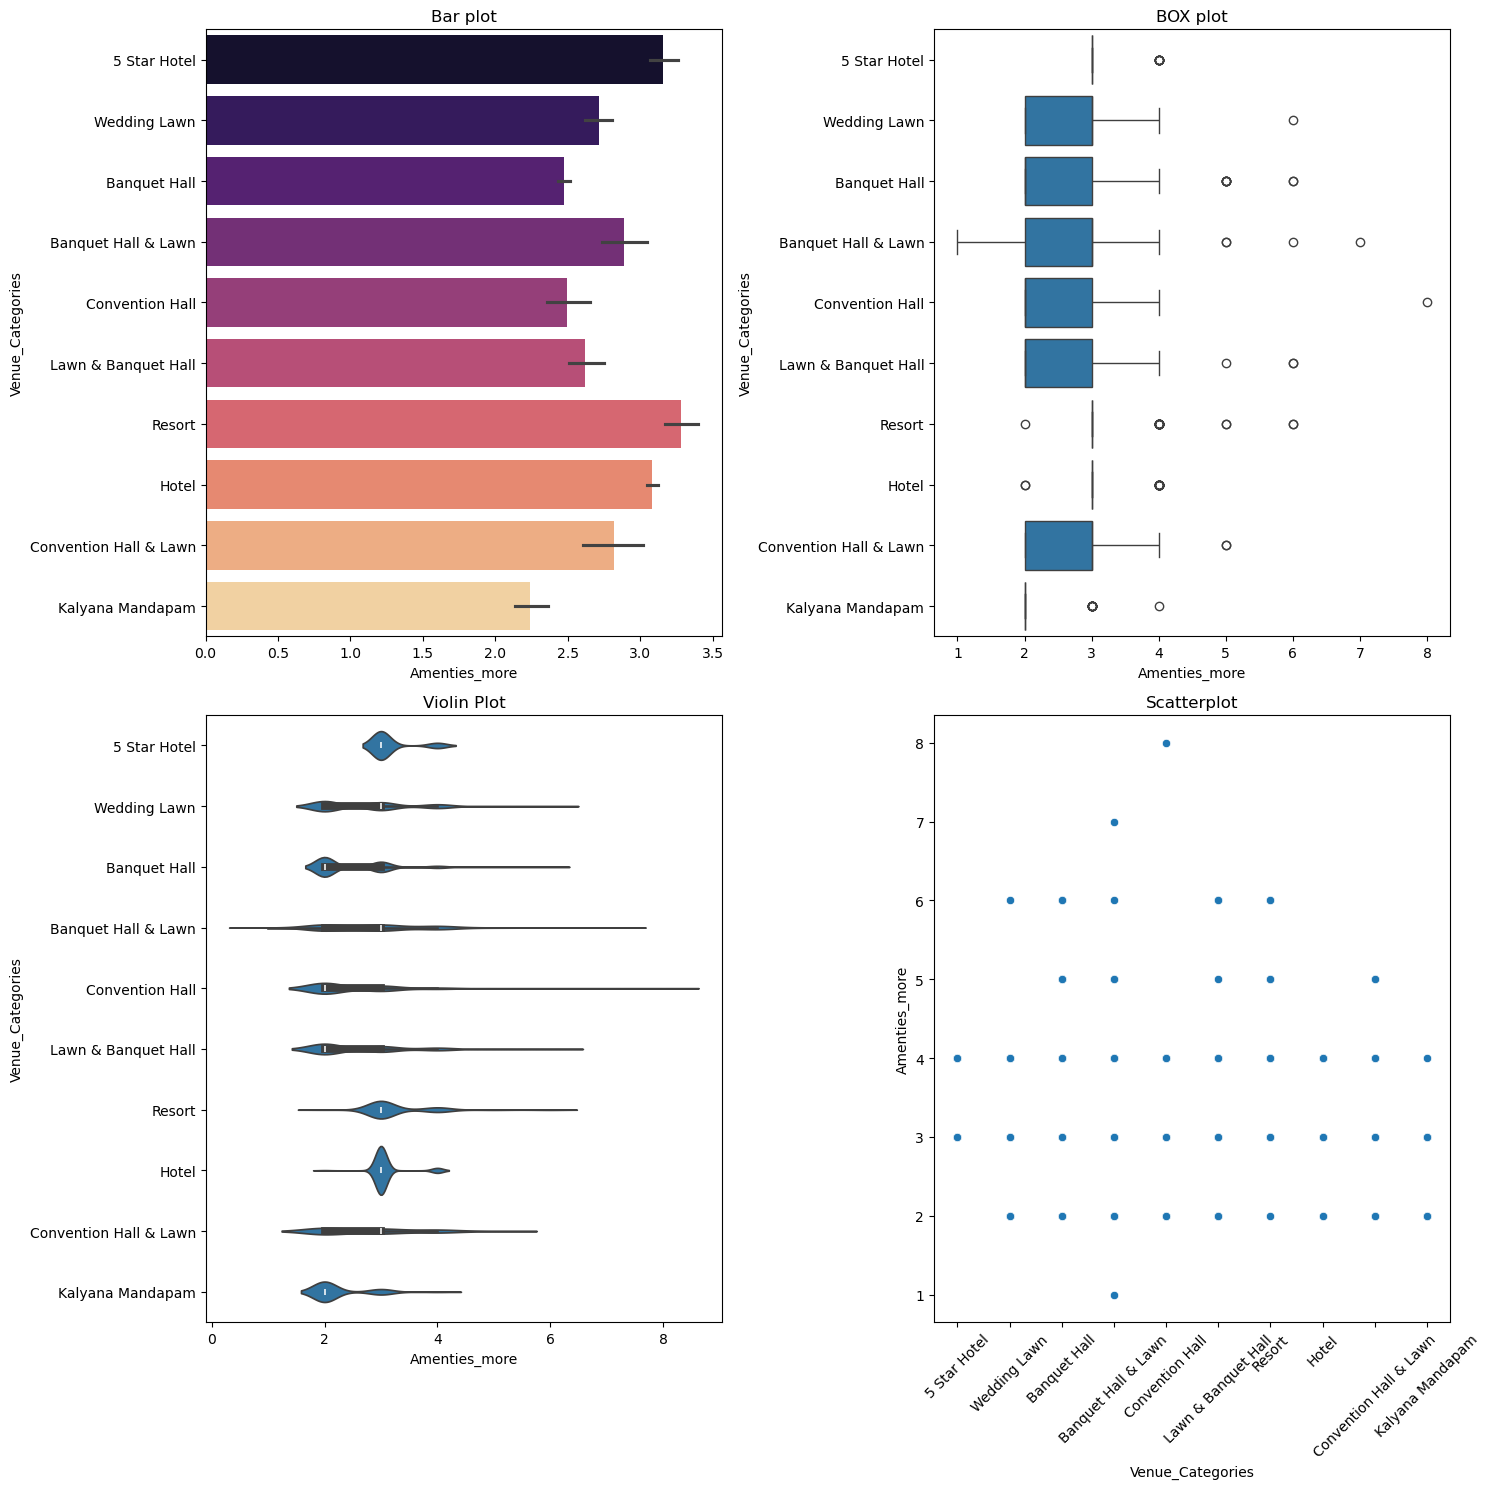

In [24]:

cat_num(data,'Venue_Categories',numerical_columns)

                 mean  median  min  max
Destination                            
Bangalore    4.922864     4.9  4.5  5.0
Chennai      4.923291     4.9  4.5  5.0
Hyderabad    4.927919     5.0  4.5  5.0
Lucknow      4.894684     4.9  4.5  5.0
Mumbai       4.911675     5.0  4.5  5.0
Pune         4.907888     4.9  4.5  5.0


C:\Users\HP\AppData\Local\Temp\ipykernel_15556\2015034743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= dataframe,y=categorical, x= num,palette="magma")


Saved plot: Destination_vs_Ratings.png


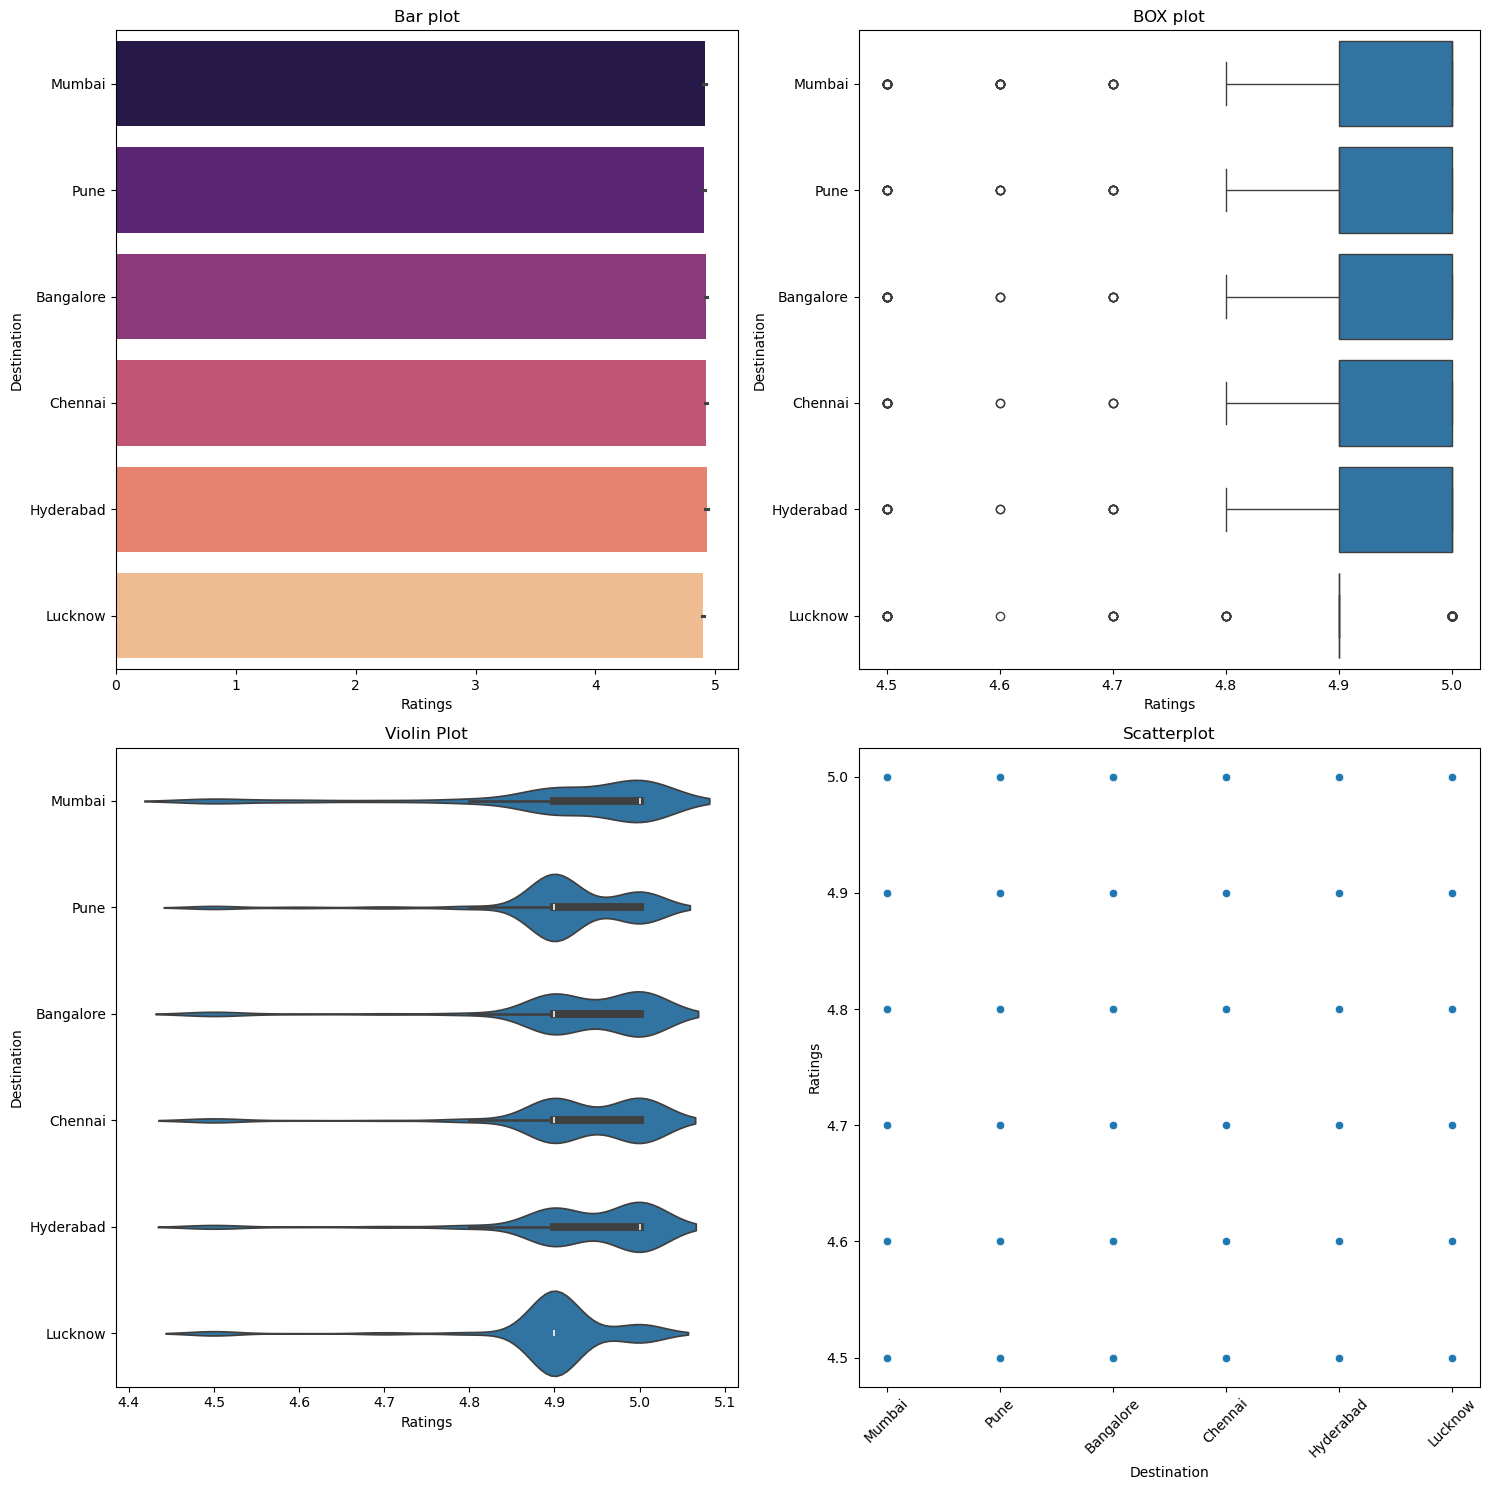

                 mean  median  min    max
Destination                              
Bangalore    3.414573     2.0  1.0   49.0
Chennai      3.223797     3.0  1.0   45.0
Hyderabad    3.040102     2.0  1.0   26.0
Lucknow      4.841013     3.8  1.0   72.0
Mumbai       4.217259     2.0  1.0  161.0
Pune         4.144020     3.8  1.0  212.0


C:\Users\HP\AppData\Local\Temp\ipykernel_15556\2015034743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= dataframe,y=categorical, x= num,palette="magma")


Saved plot: Destination_vs_Reviews.png


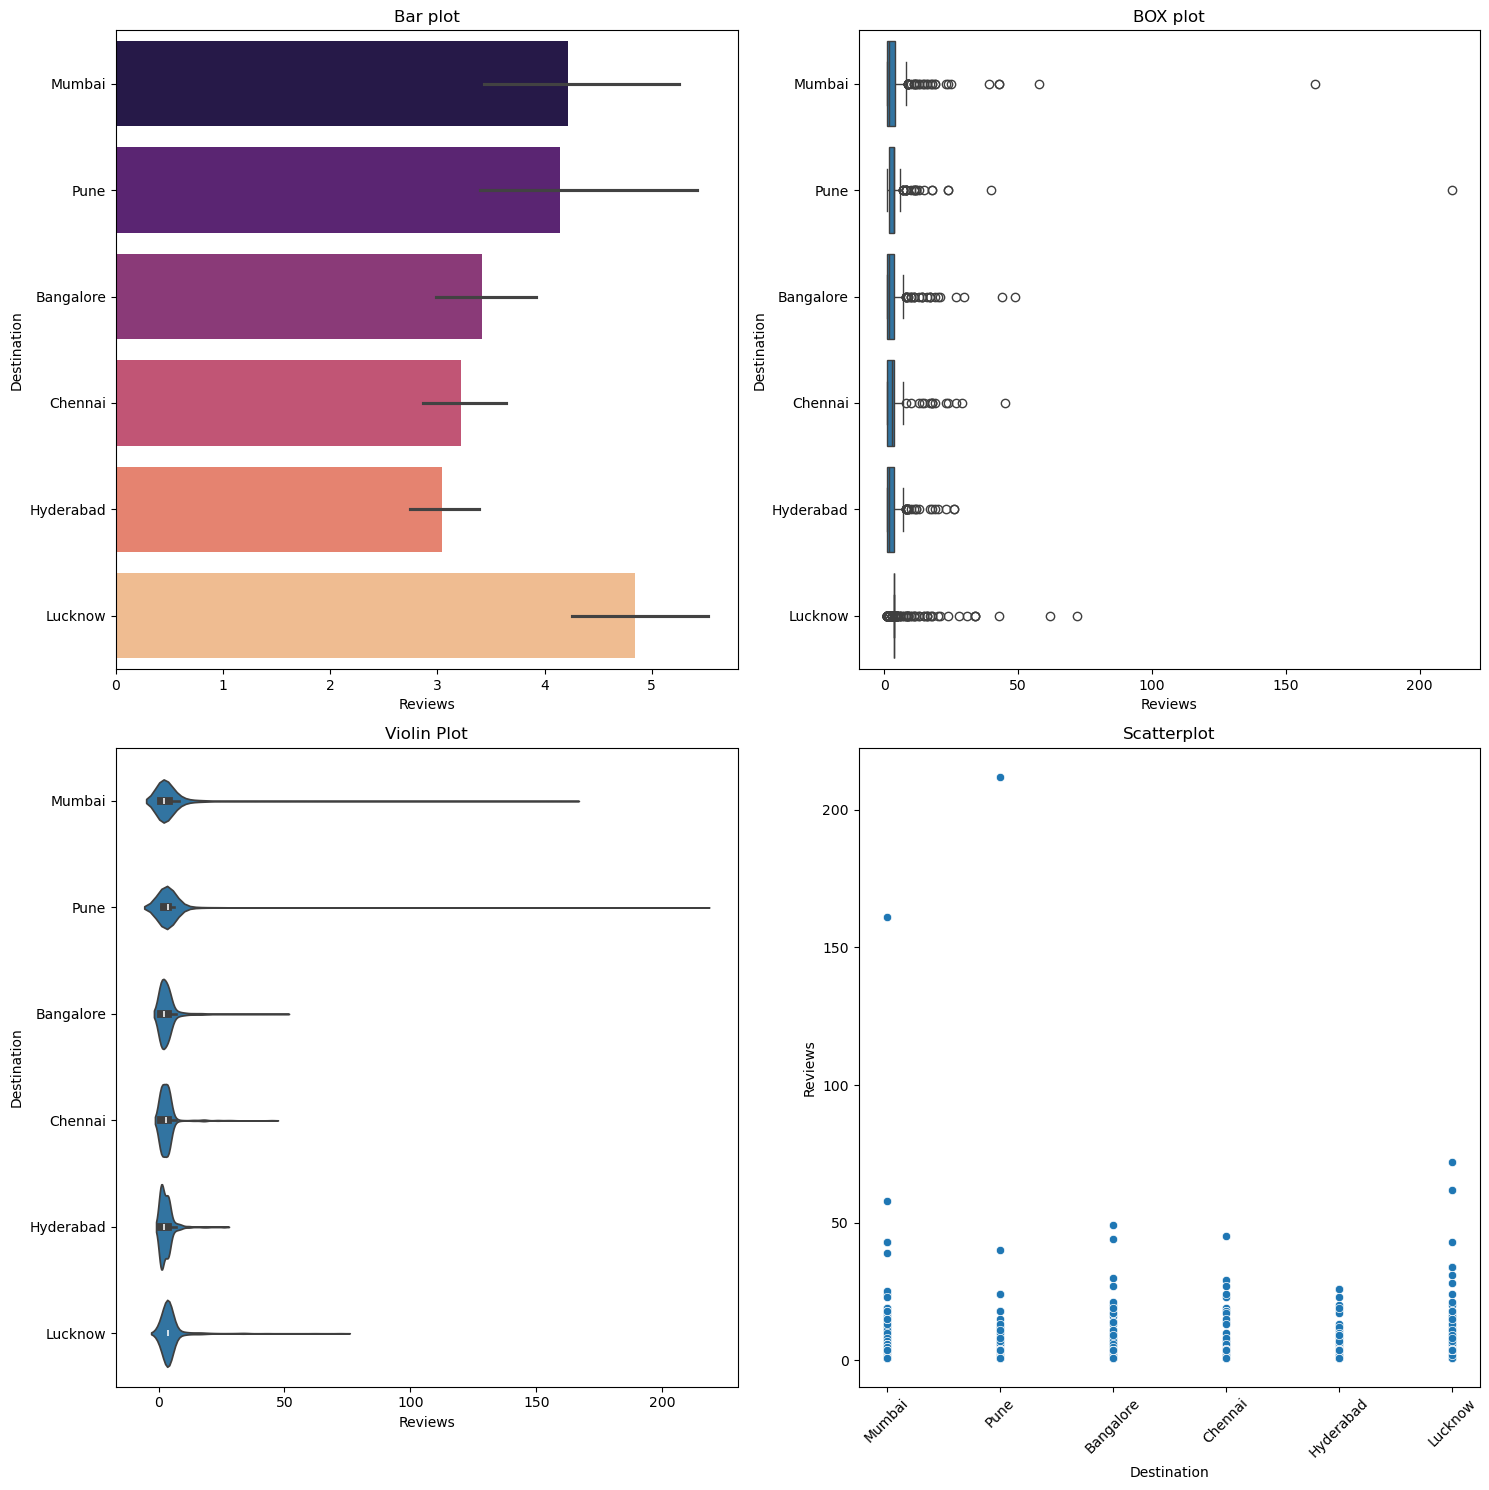

                     mean  median  min      max
Destination                                    
Bangalore    25912.726131   650.0  150  1400000
Chennai      10365.663291   650.0  150   650000
Hyderabad    29379.799492   650.0  100  2000000
Lucknow      11184.227848   700.0  150   400000
Mumbai        5783.992386   750.0  130   245000
Pune         11111.898219   650.0   23   500000


C:\Users\HP\AppData\Local\Temp\ipykernel_15556\2015034743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= dataframe,y=categorical, x= num,palette="magma")


Saved plot: Destination_vs_Menu_price.png


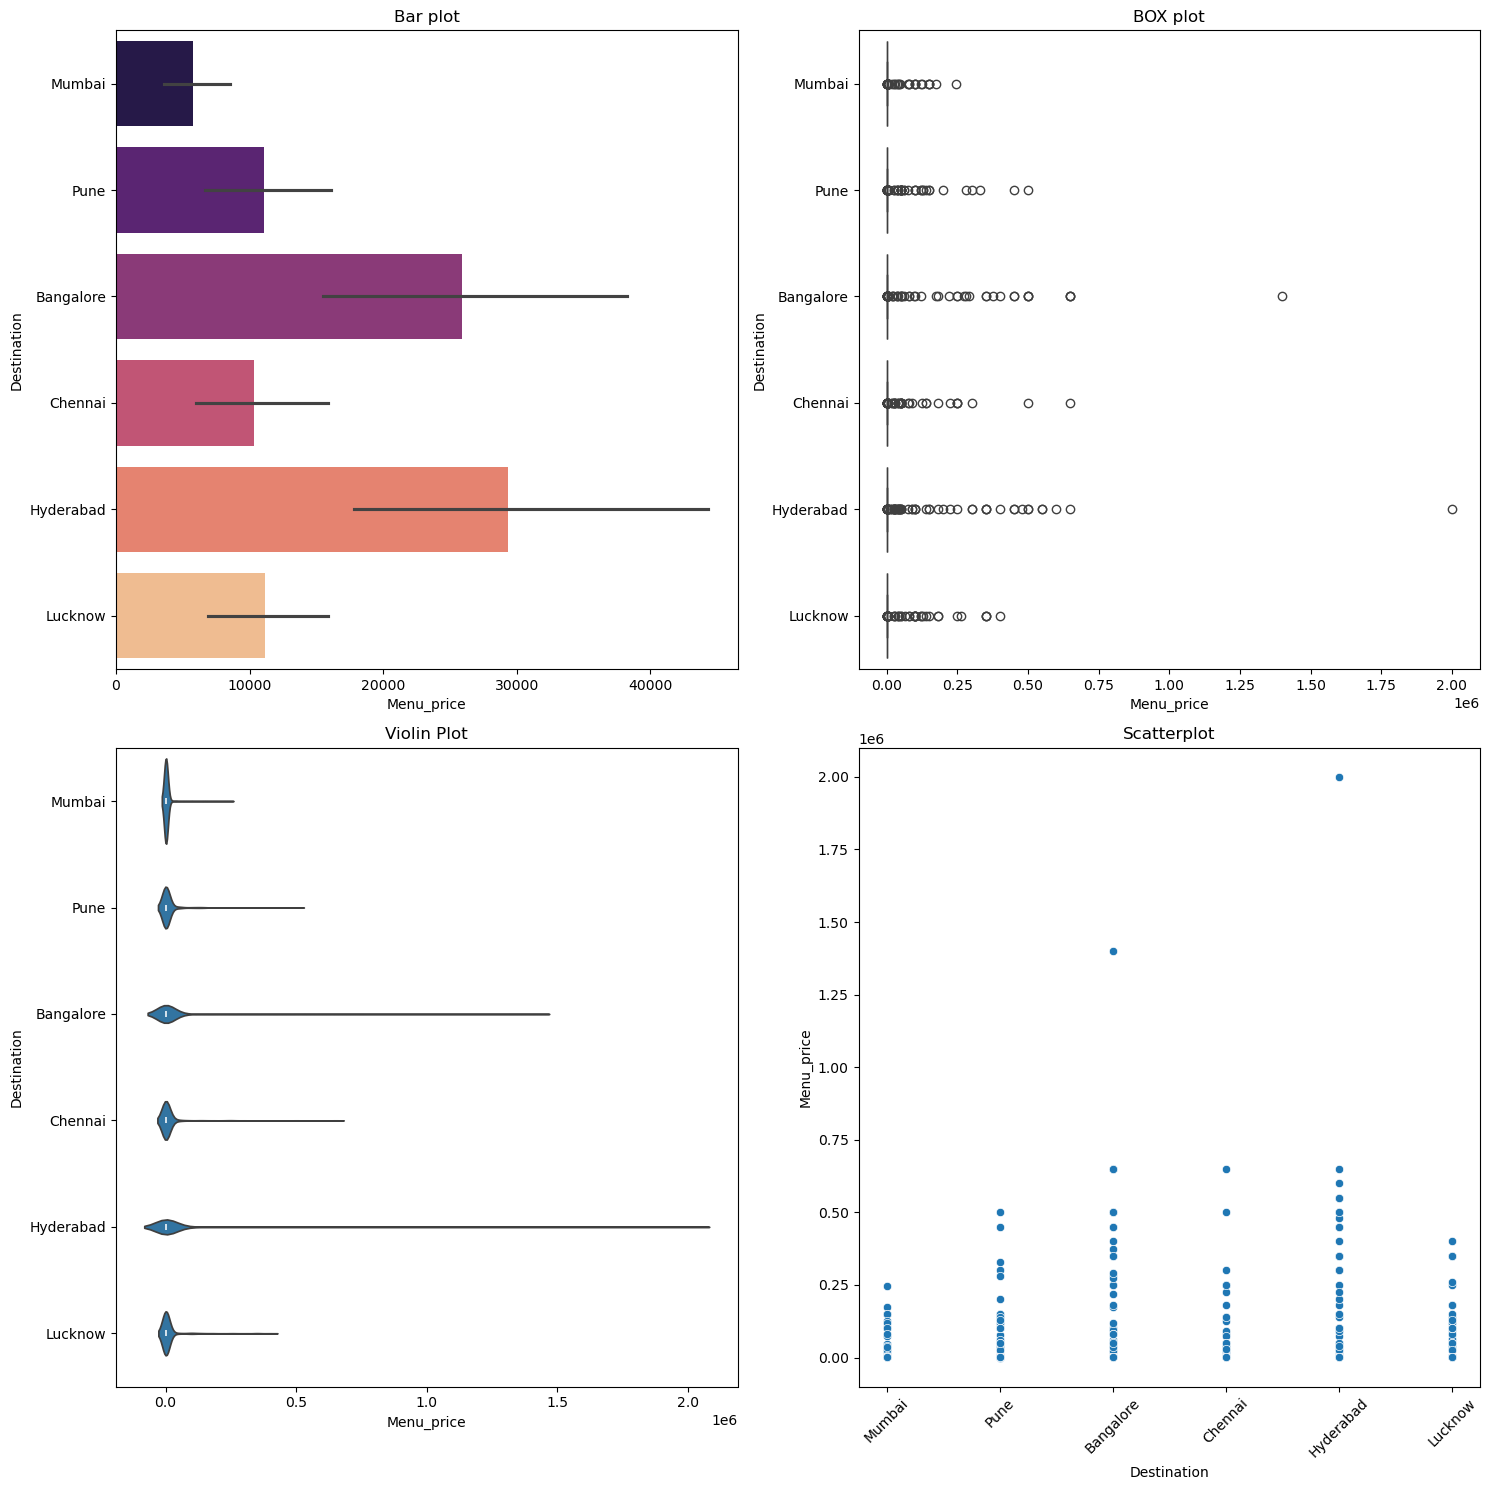

                   mean  median  min   max
Destination                               
Bangalore    289.640704   200.0    8  2500
Chennai      368.686076   250.0   15  3500
Hyderabad    355.621827   200.0   10  2500
Lucknow      351.508861   200.0   25  6000
Mumbai       266.720812   200.0    8  2500
Pune         299.010178   150.0   15  2500


C:\Users\HP\AppData\Local\Temp\ipykernel_15556\2015034743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= dataframe,y=categorical, x= num,palette="magma")


Saved plot: Destination_vs_Capacity_min.png


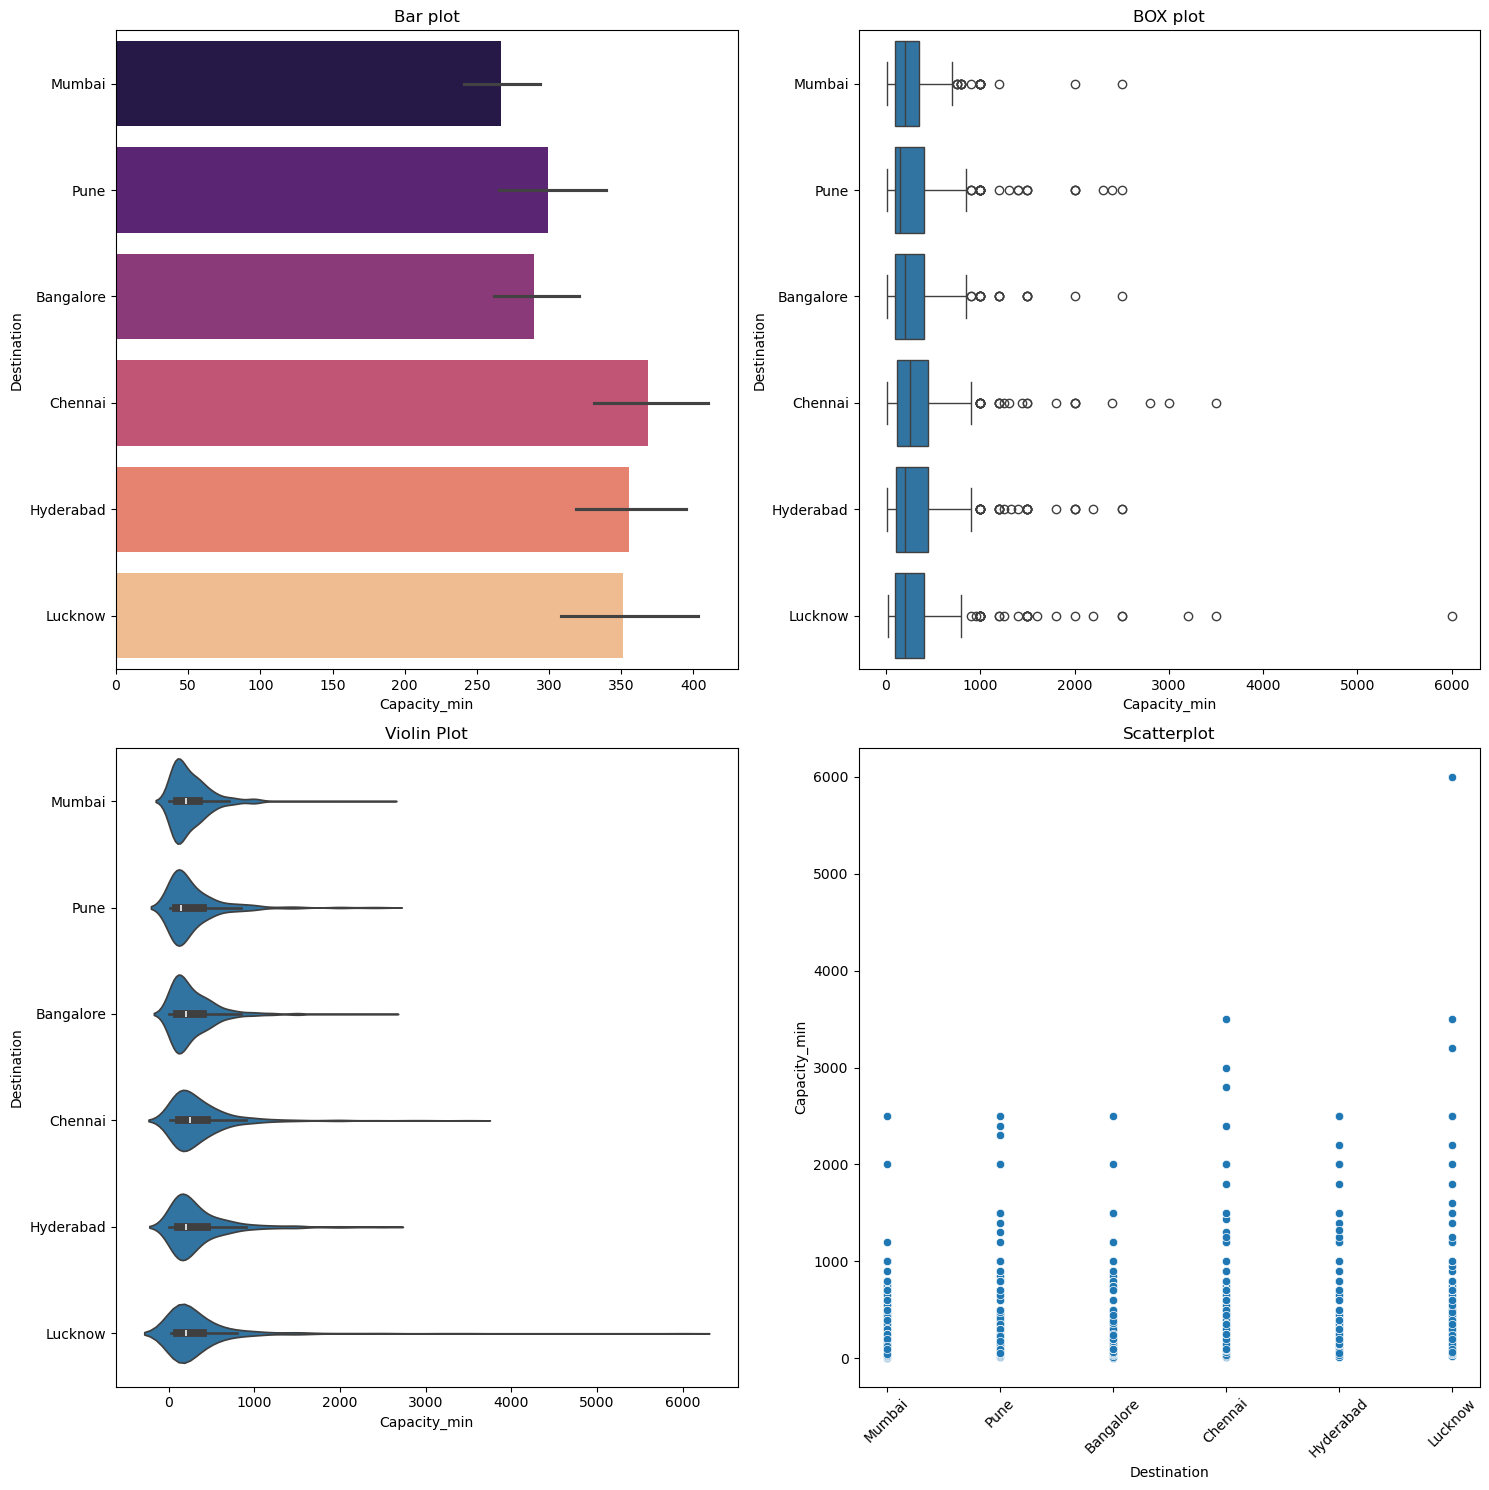

                   mean  median  min    max
Destination                                
Bangalore    833.442211   500.0   70  10000
Chennai      753.012658   500.0   50   7500
Hyderabad    914.758883   600.0   60   8000
Lucknow      773.794937   500.0    4   7000
Mumbai       790.431472   600.0   50  12000
Pune         769.262087   500.0   50   5000


C:\Users\HP\AppData\Local\Temp\ipykernel_15556\2015034743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= dataframe,y=categorical, x= num,palette="magma")


Saved plot: Destination_vs_Capacity_max.png


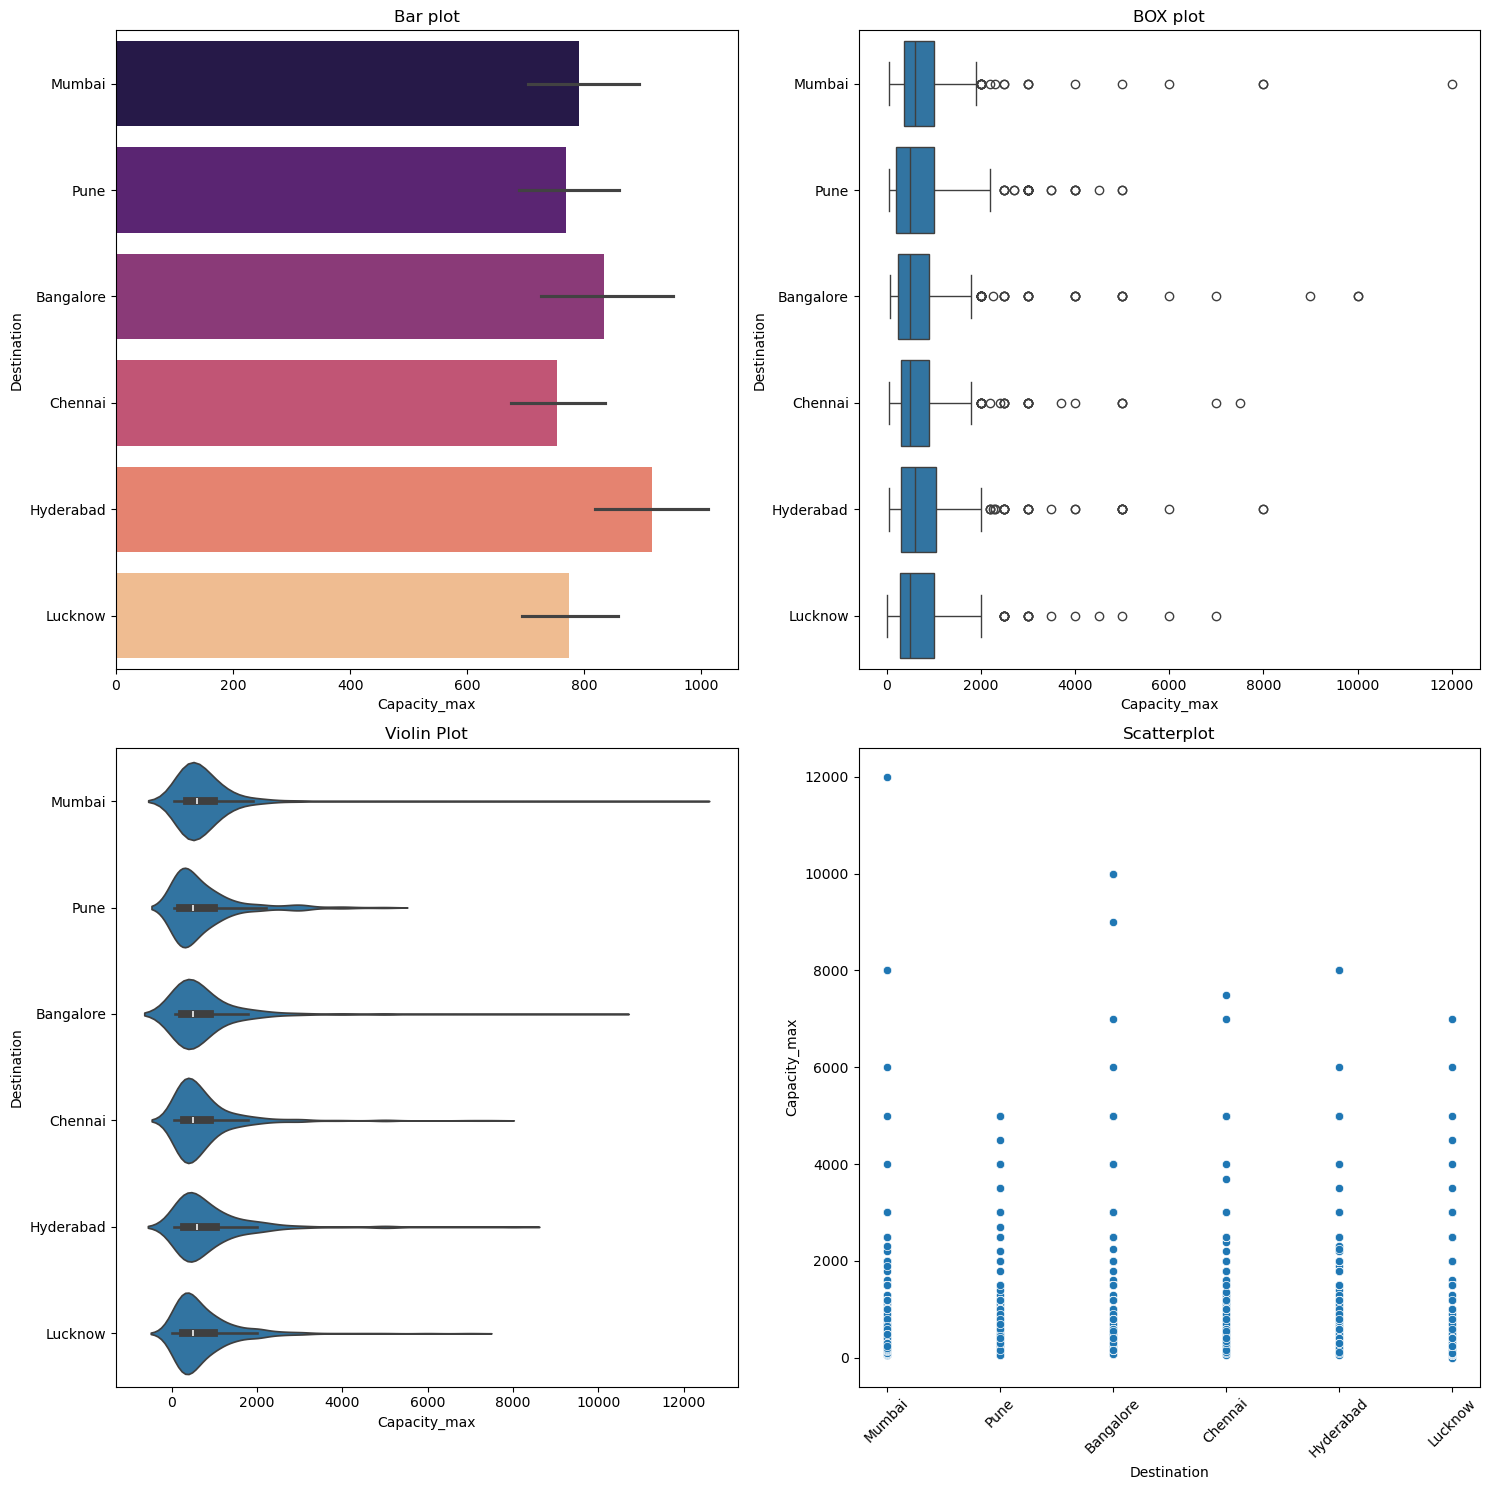

                  mean  median  min  max
Destination                             
Bangalore    36.047739    20.0    1  520
Chennai      31.351899    20.0    1  325
Hyderabad    29.791878    20.0    1  427
Lucknow      26.250633    20.0    1  700
Mumbai       42.218274    20.0    1  669
Pune         32.585242    20.0    1  416


C:\Users\HP\AppData\Local\Temp\ipykernel_15556\2015034743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= dataframe,y=categorical, x= num,palette="magma")


Saved plot: Destination_vs_Rooms.png


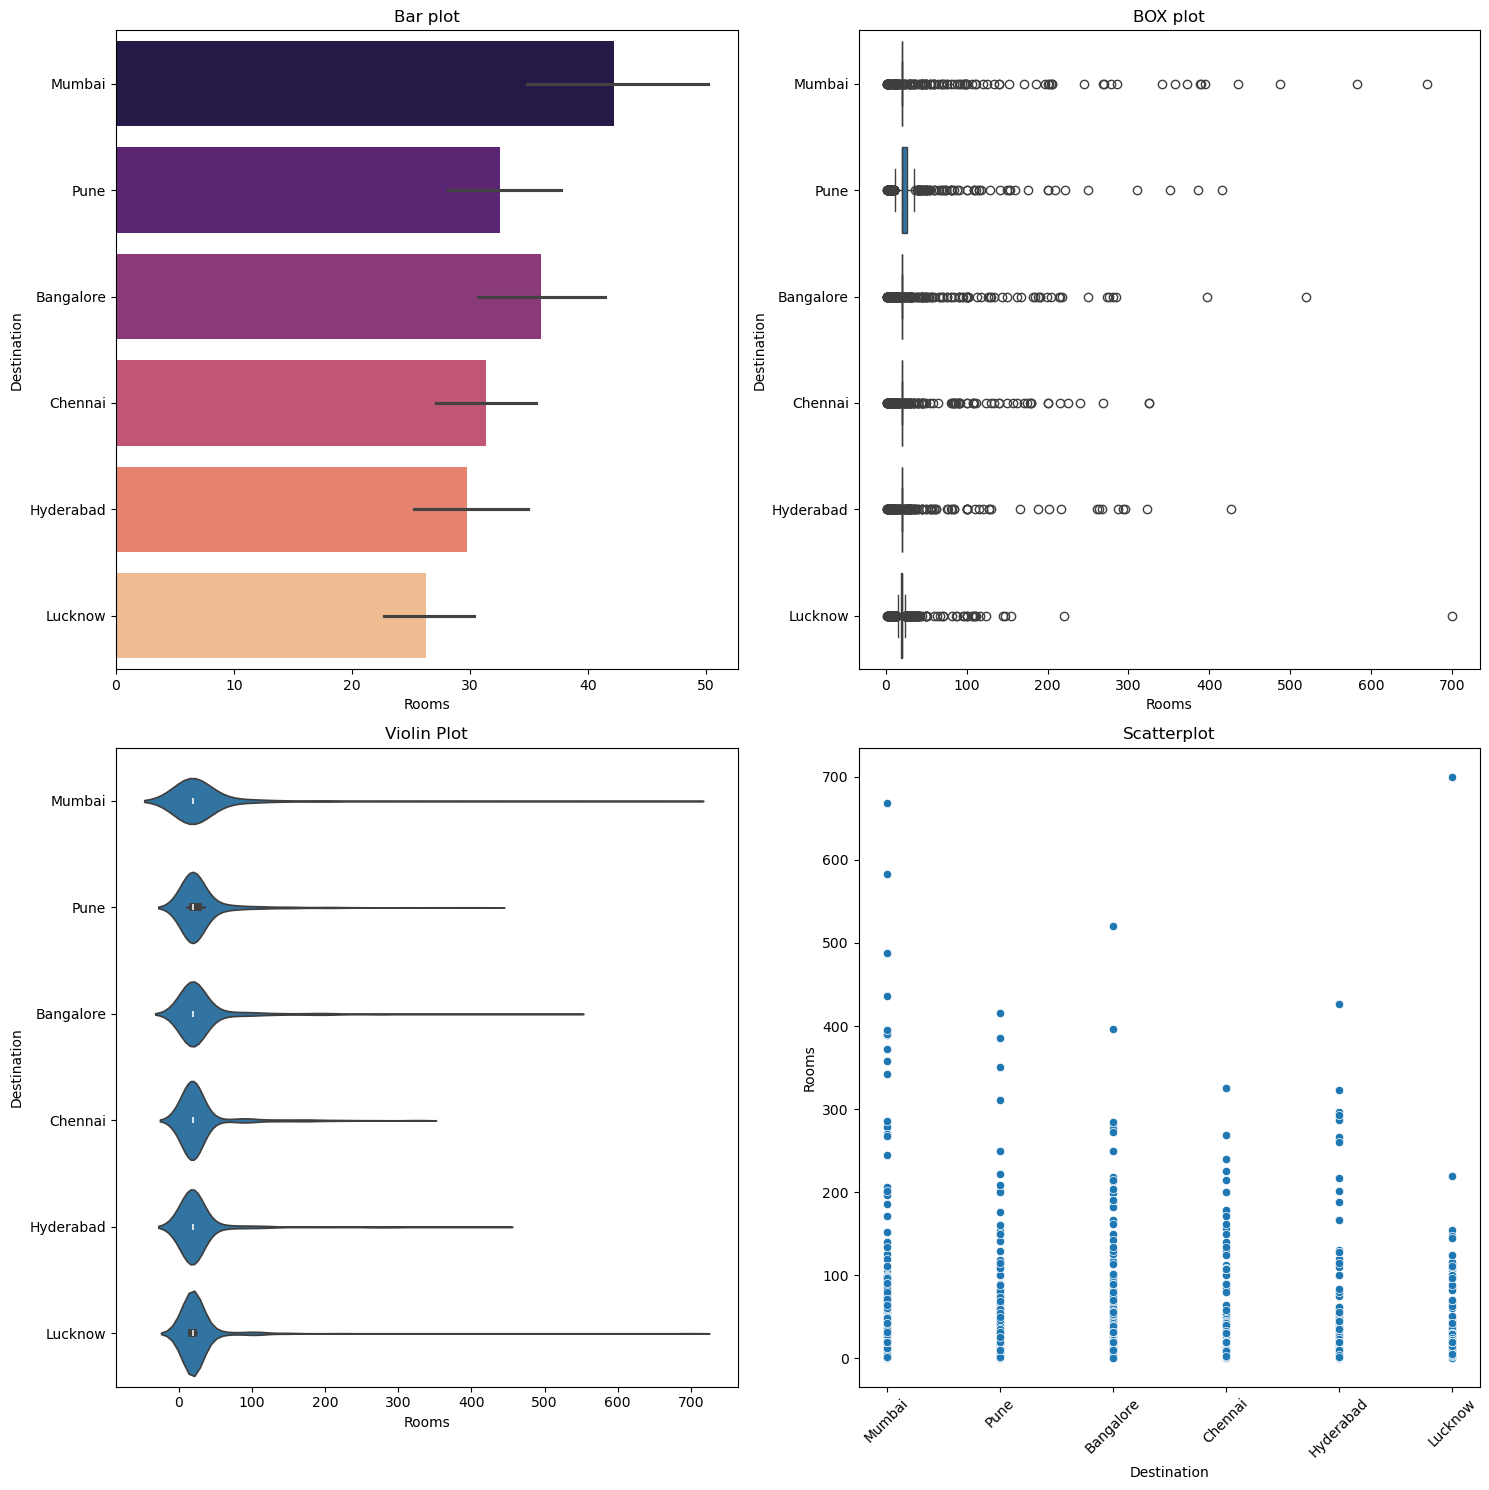

                 mean  median  min  max
Destination                            
Bangalore    2.716080     3.0    2    7
Chennai      2.670886     3.0    2    8
Hyderabad    2.738579     3.0    2    8
Lucknow      2.754430     3.0    2    7
Mumbai       2.753807     3.0    1    6
Pune         2.743003     3.0    2    6


C:\Users\HP\AppData\Local\Temp\ipykernel_15556\2015034743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= dataframe,y=categorical, x= num,palette="magma")


Saved plot: Destination_vs_Amenties_more.png


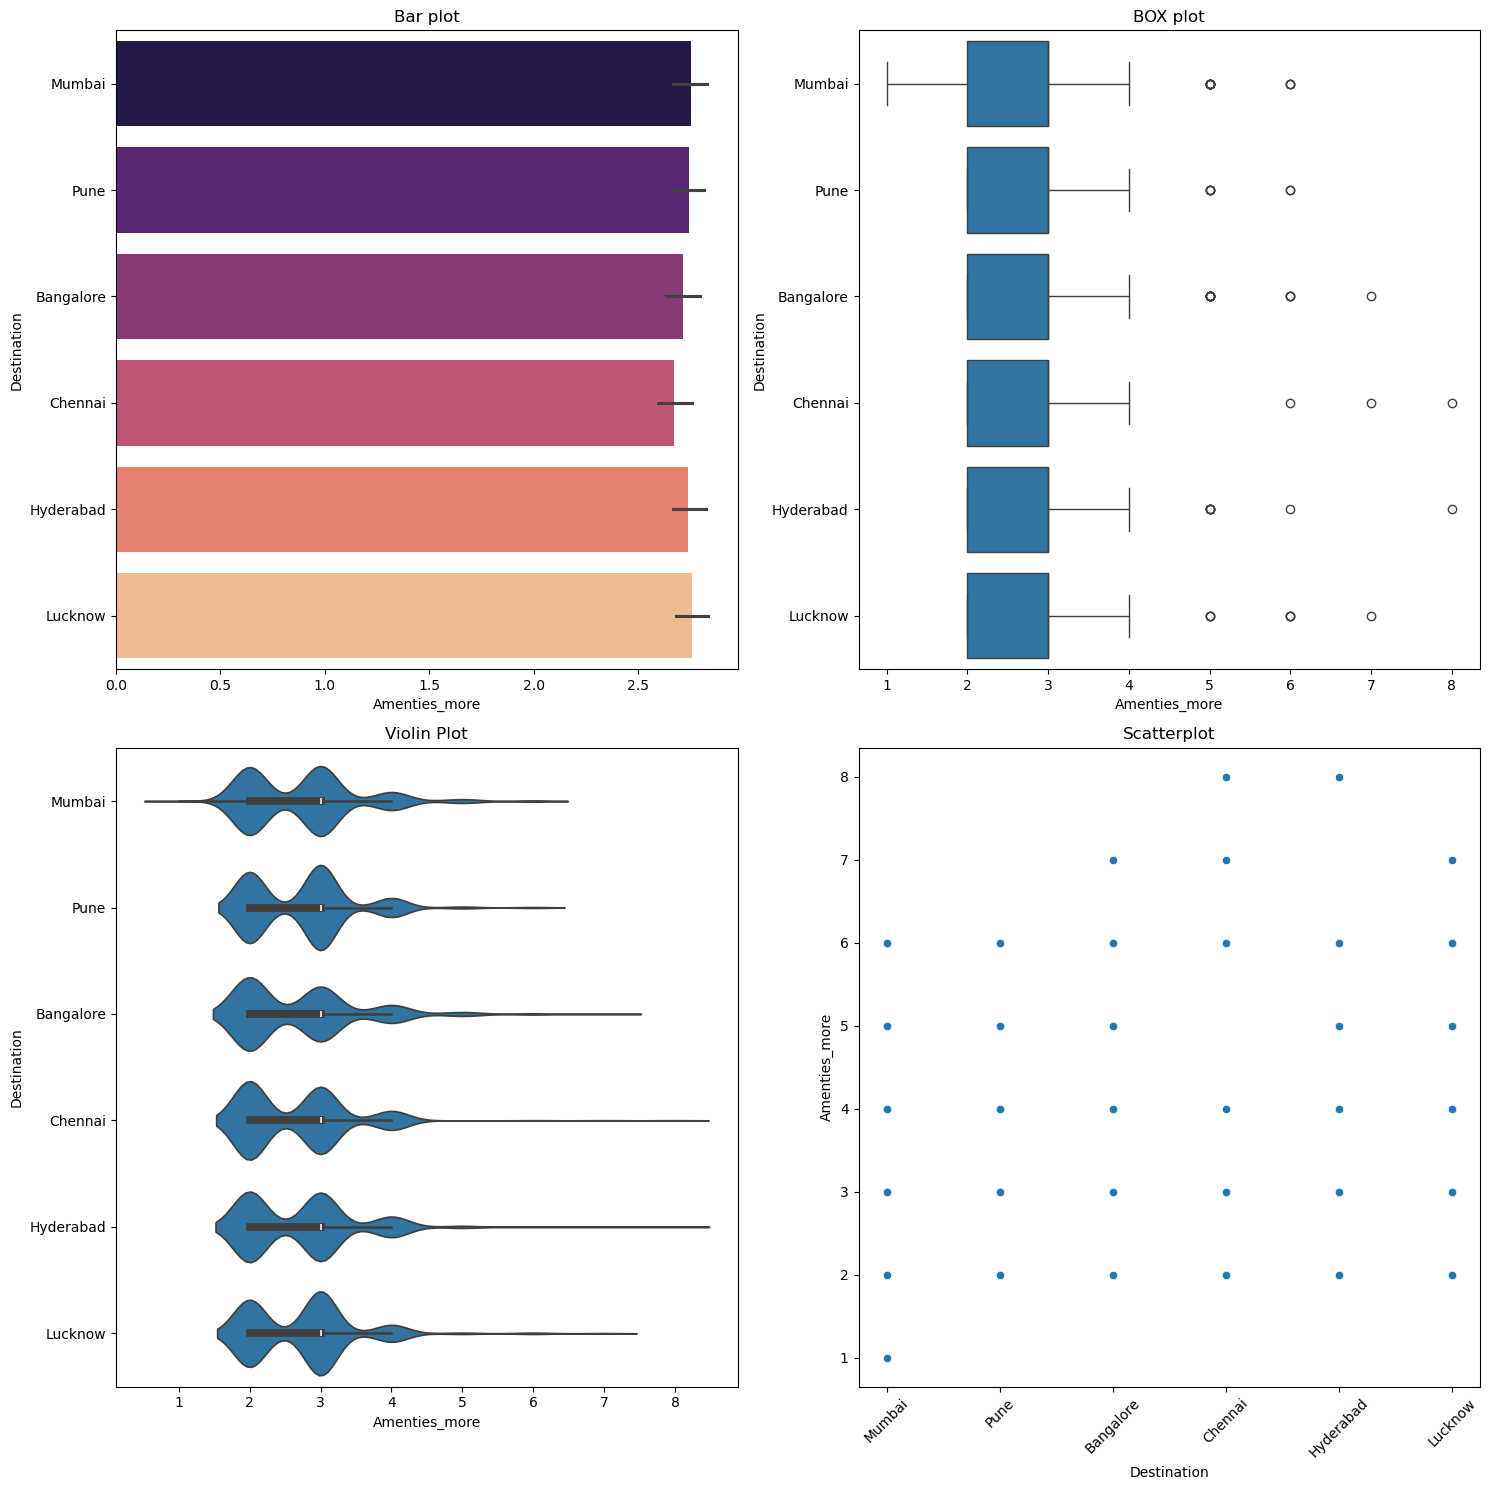

In [25]:
cat_num(data,'Destination',numerical_columns)

 # Categorical Vs Categorical

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def cat_n_cat(data, column1, column2, head=10): ## head to get the most frqeuent cat
    # Create a contingency table (cross-tabulation)
    contingency_table = pd.crosstab(data[column1], data[column2])
    
    top_values = contingency_table.sum(axis=1).nlargest(head).index
    contingency_table = contingency_table.loc[top_values]
    filt = data[data[column1].isin(top_values)]
    
    contingency_table_percent = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100 # Convert contingency table to percentages
    print(contingency_table_percent)
    plt.figure(figsize=(15, 6))
    
    # Bar plot 
    plt.subplot(1, 2, 1)
    sns.barplot(data=contingency_table_percent.T, orient='h')
    plt.xlabel('Percentage')
    plt.ylabel(f'{column1}')
    plt.title(f'Top {head} Categories in {column1} vs {column2}')
    plt.tight_layout()
    
    # Heatmap of the percentages
    plt.subplot(1, 2, 2)
    sns.countplot(data=filt, y=column1, hue=column2)
    plt.xlabel(f'{column2}')
    plt.ylabel(f'{column1}')
    plt.title(f'Heatmap of {column1} vs {column2}')
    plt.tight_layout()
    plt.savefig("Categoeical vs Cateogorical.png")
    plt.show()

Destination             Bangalore    Chennai  Hyderabad    Lucknow     Mumbai  \
Venue_Categories                                                                
Banquet Hall            16.075388  20.731707  14.855876  12.416851  21.396896   
Wedding Lawn            10.583942   6.204380  12.408759  34.671533  14.233577   
Hotel                   19.341564  18.106996  13.991770  16.460905  12.345679   
Lawn & Banquet Hall      6.666667  10.555556  13.888889  30.000000  13.333333   
Banquet Hall & Lawn     11.029412   9.558824  13.970588  30.147059  12.500000   
Convention Hall         33.628319  32.743363  30.088496   0.000000   3.539823   
Resort                  16.216216  12.612613  17.117117  12.612613  11.711712   
Convention Hall & Lawn  11.475410  13.114754  73.770492   0.000000   0.000000   
5 Star Hotel            25.862069  18.965517  15.517241   3.448276  25.862069   
Kalyana Mandapam        48.275862  37.931034  13.793103   0.000000   0.000000   

Destination                

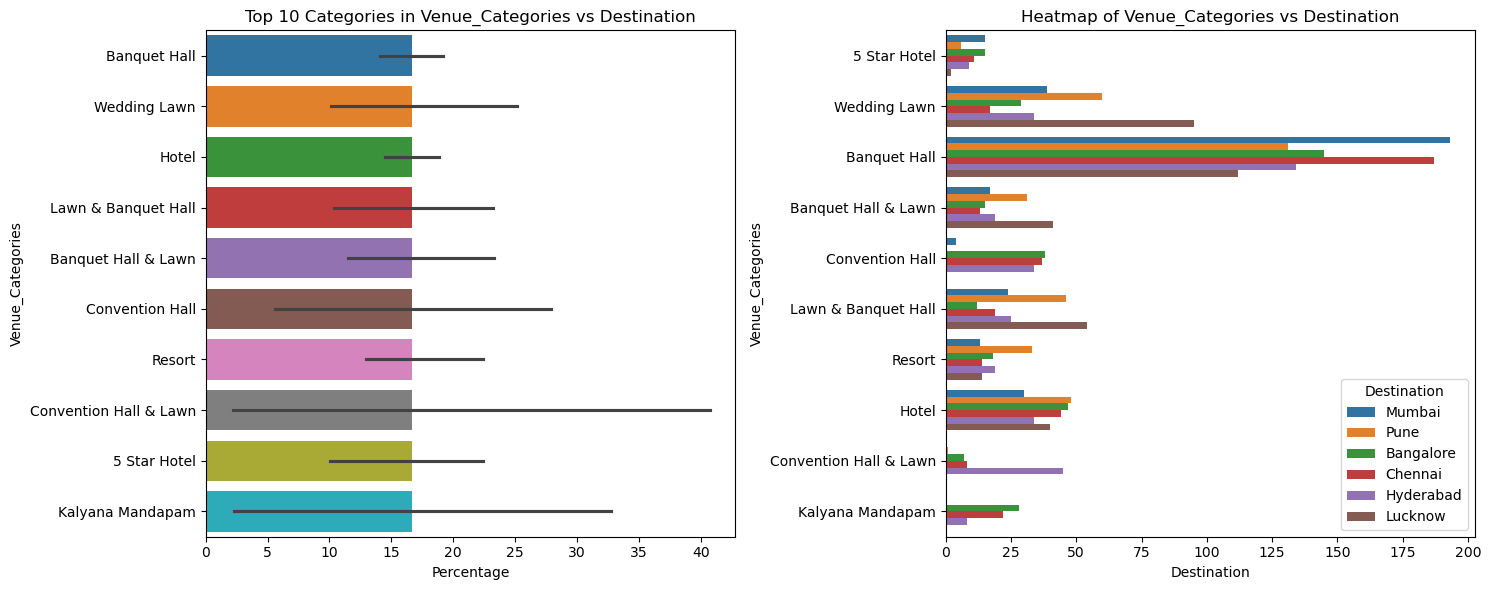

In [27]:
cat_n_cat(data,'Venue_Categories','Destination')

Destination                               Bangalore  Chennai  Hyderabad  \
Name                                                                      
Atlantis                                        0.0     50.0        0.0   
Madhav Banquet                                  0.0      0.0        0.0   
Sri Kuchalambal Kalyana Mahal                  50.0     50.0        0.0   
The Bee Farm                                    0.0      0.0        0.0   
Welcome Hall                                    0.0      0.0        0.0   
Whistling Woodzs Jungle Resort, Dandeli         0.0      0.0       50.0   
 NSCI Dome                                      0.0      0.0        0.0   
 Shorba Family Restaurant, Sinhagad Road        0.0      0.0        0.0   
 Summer Green Resorts                           0.0      0.0      100.0   
17 Degrees North Club                           0.0      0.0      100.0   

Destination                               Lucknow  Mumbai   Pune  
Name                            

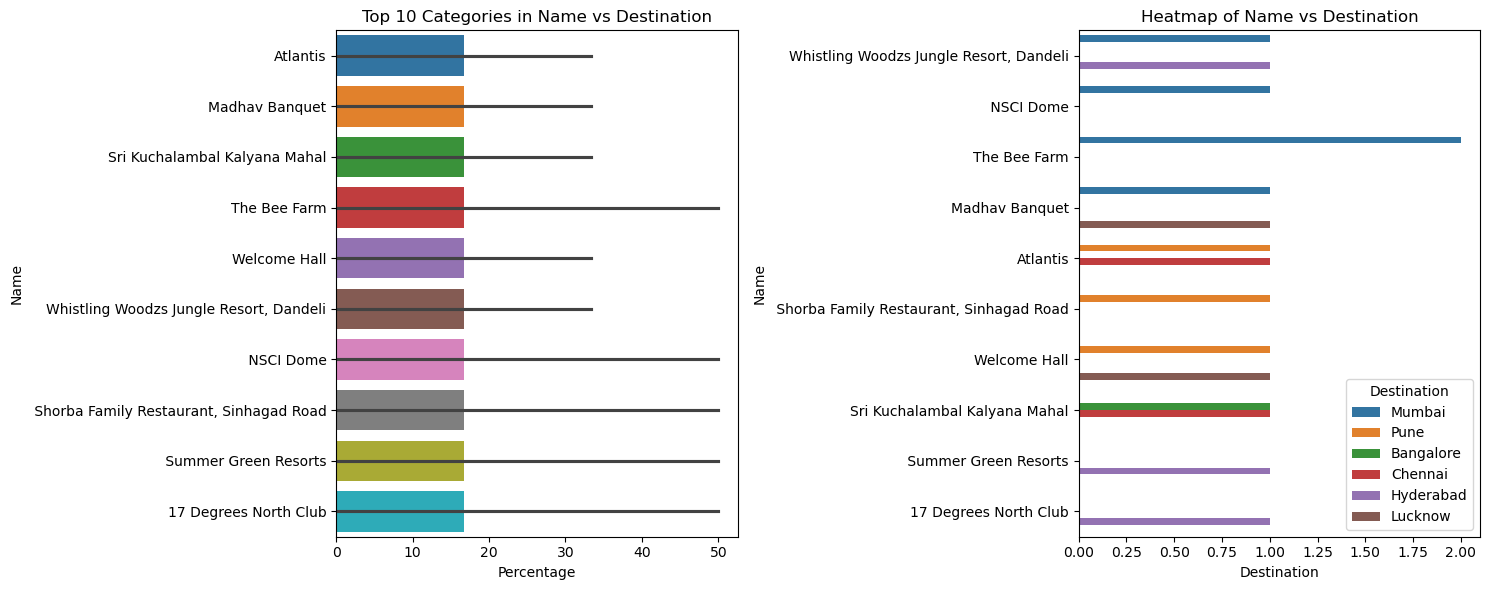

In [28]:
cat_n_cat(data,'Name','Destination')

# Grouped Bar Chart

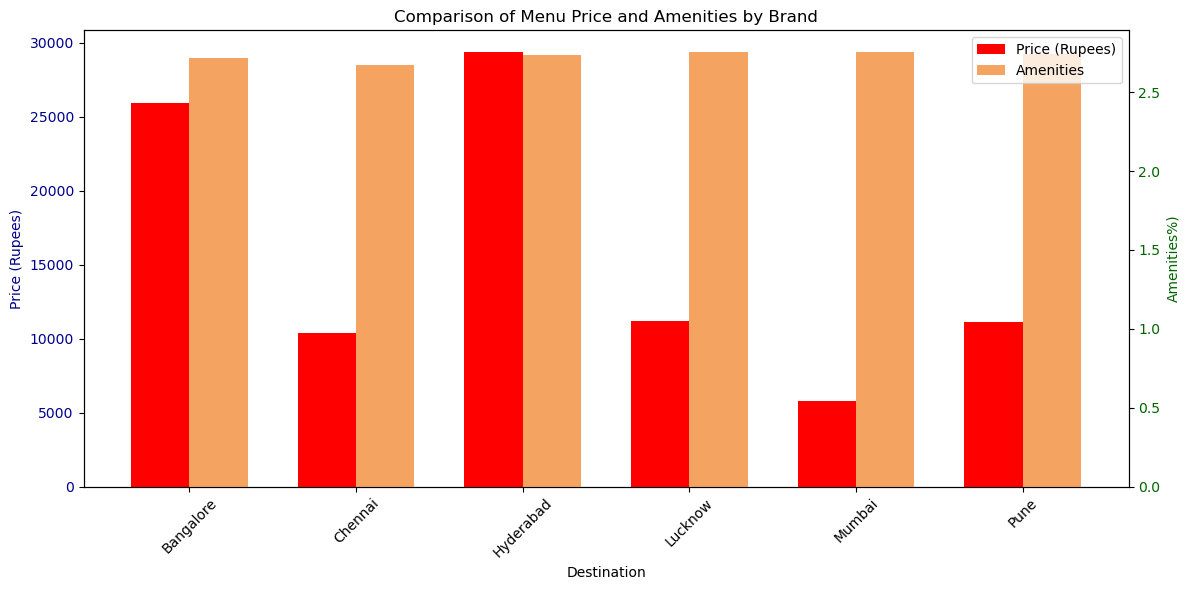

In [29]:


import numpy as np
grouped = data.groupby('Destination')[['Menu_price', 'Amenties_more']].mean().reset_index()

# Set position of bars on X axis
Destination = grouped['Destination']
x = np.arange(len(Destination))
width = 0.35

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis for Price
bar1 = ax1.bar(x - width/2, grouped['Menu_price'], width, label='Price (Rupees)', color='red')
ax1.set_ylabel('Price (Rupees)', color='darkblue')
ax1.tick_params(axis='y', labelcolor='darkblue')

# Secondary axis for ABV%
ax2 = ax1.twinx()
bar2 = ax2.bar(x + width/2, grouped['Amenties_more'], width, label='Amenities', color='SANDYBROWN')
ax2.set_ylabel('Amenities%)', color='DARKGREEN')
ax2.tick_params(axis='y', labelcolor='DARKGREEN')

# X-axis settings
ax1.set_xlabel('Destination')
ax1.set_xticks(x)
ax1.set_xticklabels(Destination, rotation=45)

# Title
plt.title('Comparison of Menu Price and Amenities by Brand')

# Legends
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

plt.tight_layout()
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_15556\3860514785.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Destination', y='Menu_price', palette='Oranges')


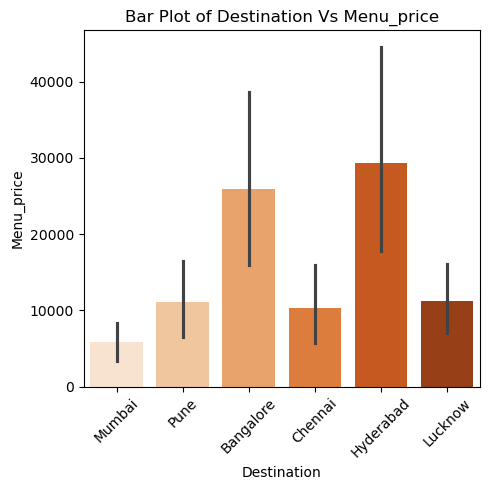

In [30]:
plt.figure(figsize=(5,5))
sns.barplot(data=data, x='Destination', y='Menu_price', palette='Oranges')
plt.xticks(rotation=45)
plt.title('Bar Plot of Destination Vs Menu_price')
plt.tight_layout()
plt.show()